## 0. Setup

Load libraries, set display options, define file paths, and create the figures folder.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# seed for reproducibility
SEED = 42
np.random.seed(SEED)

# show more columns in df.head() since the main table has 122
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 200)

# mount google drive so we can read the csvs from the shared project folder
from google.colab import drive
drive.mount('/content/drive')

# data folder
DATA_DIR = "/content/drive/MyDrive/MLDL/loan-default-project/01_data/01_raw"

Mounted at /content/drive


## 1. Loading data

We work only with `application_train.csv`

In [2]:
# importing the only table we will work on

df = pd.read_csv(f"{DATA_DIR}/application_train.csv")
df_unlabeled = pd.read_csv(f"{DATA_DIR}/application_test.csv")

In [3]:
# checking the shape

print("Shape:", df.shape)
print("Shape:", df_unlabeled.shape)


Shape: (307511, 122)
Shape: (48744, 121)


We work only with `application_train.csv`. The Kaggle competition's `application_test.csv` has no `TARGET` column since the labels were never released after the competition closed, so we cannot score any model on it. Our train/validation/test split is done inside `application_train.csv` instead.

In [4]:
# checking the df head

df.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
# checking basic info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
# we reprint so it is more readable

df.dtypes.value_counts()

,count
float64,65
int64,41
object,16


## 2. Target Variable

we check how often default happens in the training data and how imbalanced the classes are.

The target variable `TARGET` is binary and flags whether an applicant had
payment difficulties:

- `1` = the client had late payment of more than X days on at least one of
  the first Y installments of the loan (the "bad" outcome we want to predict)
- `0` = all other cases, including loans paid on time and minor delays

In [7]:
# cointing how many 0s and 1s we have in the target column
counts = df["TARGET"].value_counts().sort_index()

# we take the result and examine that as a percentage
pct = (counts / len(df)) * 100

# put them side by side in a dataframe
target_summary = pd.DataFrame({"count": counts, "pct": pct.round(2)})

# we determine the default ratio
ratio = counts[0] / counts[1]


print(f"\n1 defaulter per {ratio:.1f} non-defaulters")
target_summary


1 defaulter per 11.4 non-defaulters


,count,pct
TARGET,,
0,282686,91.93
1,24825,8.07


In [8]:
# overall default rate, used as a reference line in bivariate plots
default_rate = df["TARGET"].mean()

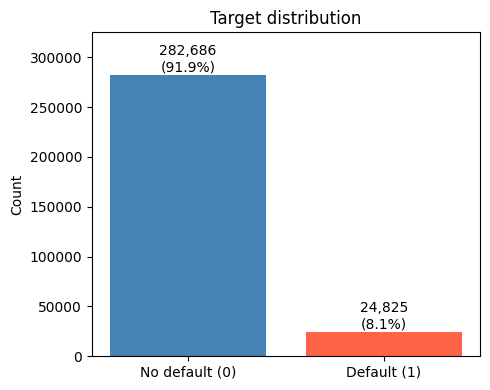

In [9]:
# plotting the results above

plt.figure(figsize=(5, 4))
plt.bar(["No default (0)", "Default (1)"], counts.values, color=["steelblue", "tomato"])

# add count and percentage labels on top of each bar
for i, (cnt, p) in enumerate(zip(counts.values, pct.values)):
    plt.text(i, cnt, f"{cnt:,}\n({p:.1f}%)", ha="center", va="bottom")

# extend the y-axis because it was hitting the label
plt.ylim(0, counts.max() * 1.15)

plt.ylabel("Count")
plt.title("Target distribution")
plt.tight_layout()
plt.show()

As we can see the dataset is heavily imbalanced, this is not strange for default data. Needs to get addressed.

## 3. Splitting columns by type

we separate numeric and categorical columns so we can apply the right plots and summaries to each.

In [10]:
# split column names into two lists by data type

numeric_cols = df.select_dtypes(include="number").columns.tolist()
object_cols = df.select_dtypes(include="object").columns.tolist()

# quick sanity check on the counts

print(f"numeric columns: {len(numeric_cols)}")
print(f"object columns: {len(object_cols)}")
print(f"total: {len(numeric_cols) + len(object_cols)} (should be {df.shape[1]})")

numeric columns: 106
object columns: 16
total: 122 (should be 122)


In [11]:
# id and target are not features, exclude them first

id_and_target = ["SK_ID_CURR", "TARGET"]

# a binary column has exactly 2 unique values but is stored as int so we take them out

feature_cols = [c for c in numeric_cols if c not in id_and_target]
binary_cols = [c for c in feature_cols if df[c].nunique() == 2]

# whatever is left after removing binaries is continuous/discrete

continuous_cols = [c for c in feature_cols if c not in binary_cols]

# sanity check

print(f"binary flags: {len(binary_cols)}")
print(f"continuous / discrete: {len(continuous_cols)}")
print(f"id + target: {len(id_and_target)}")
print(f"total: {len(binary_cols) + len(continuous_cols) + len(id_and_target)} (should be {len(numeric_cols)})")

binary flags: 32
continuous / discrete: 72
id + target: 2
total: 106 (should be 106)


In [12]:
# count unique values for each column in the continuous group
nunique_cont = df[continuous_cols].nunique(dropna=True)

# discrete counts = few distinct integer levels (like CNT_CHILDREN, HOUR_APPR_PROCESS_START)
discrete_cols = [c for c in continuous_cols if nunique_cont[c] <= 20]

# true continuous = amounts, ratios, days, everything with a wide numeric range

true_continuous_cols = [c for c in continuous_cols if nunique_cont[c] > 20]

# sanity check

print(f"true continuous (>20 unique): {len(true_continuous_cols)}")
print(f"discrete count  (3-20)      : {len(discrete_cols)}")
print(f"total                       : {len(true_continuous_cols) + len(discrete_cols)} "
      f"(should be {len(continuous_cols)})")

true continuous (>20 unique): 62
discrete count  (3-20)      : 10
total                       : 72 (should be 72)


In [13]:
# count how many unique values each categorical column has
cat_cardinality = (
    df[object_cols].nunique().sort_values(ascending=False).to_frame("n_unique")
)
display(cat_cardinality)

,n_unique
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,18
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,7
WALLSMATERIAL_MODE,7
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,4


`ORGANIZATION_TYPE` stands out with 58 categories, far more than any other column. One-hot encoding it as-is would add 57 sparse columns, so we will group rare categories during preprocessing. `OCCUPATION_TYPE` (18) and `NAME_INCOME_TYPE` (8) sit in a middle range and need similar attention. The rest have 7 or fewer levels and can be one-hot encoded directly.

## 4. Univariate Numeric

we look at each numeric column on its own to spot shape, scale and weird values.

### 4.1 All continuous numeric columns

histograms and boxplots across every continuous numeric column.

In [14]:
# quick info

summary = df[true_continuous_cols].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.00000,112500.000000,147150.00000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.00000,270000.000000,513531.00000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.50000,16524.000000,24903.00000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.00000,238500.000000,450000.00000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,0.00029,0.010006,0.01885,0.028663,7.250800e-02
...,...,...,...,...,...,...,...,...
OBS_30_CNT_SOCIAL_CIRCLE,306490.0,1.422245,2.400989,0.00000,0.000000,0.00000,2.000000,3.480000e+02
OBS_60_CNT_SOCIAL_CIRCLE,306490.0,1.405292,2.379803,0.00000,0.000000,0.00000,2.000000,3.440000e+02
DAYS_LAST_PHONE_CHANGE,307510.0,-962.858788,826.808487,-4292.00000,-1570.000000,-757.00000,-274.000000,0.000000e+00
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.00000,0.000000,0.00000,0.000000,2.700000e+01


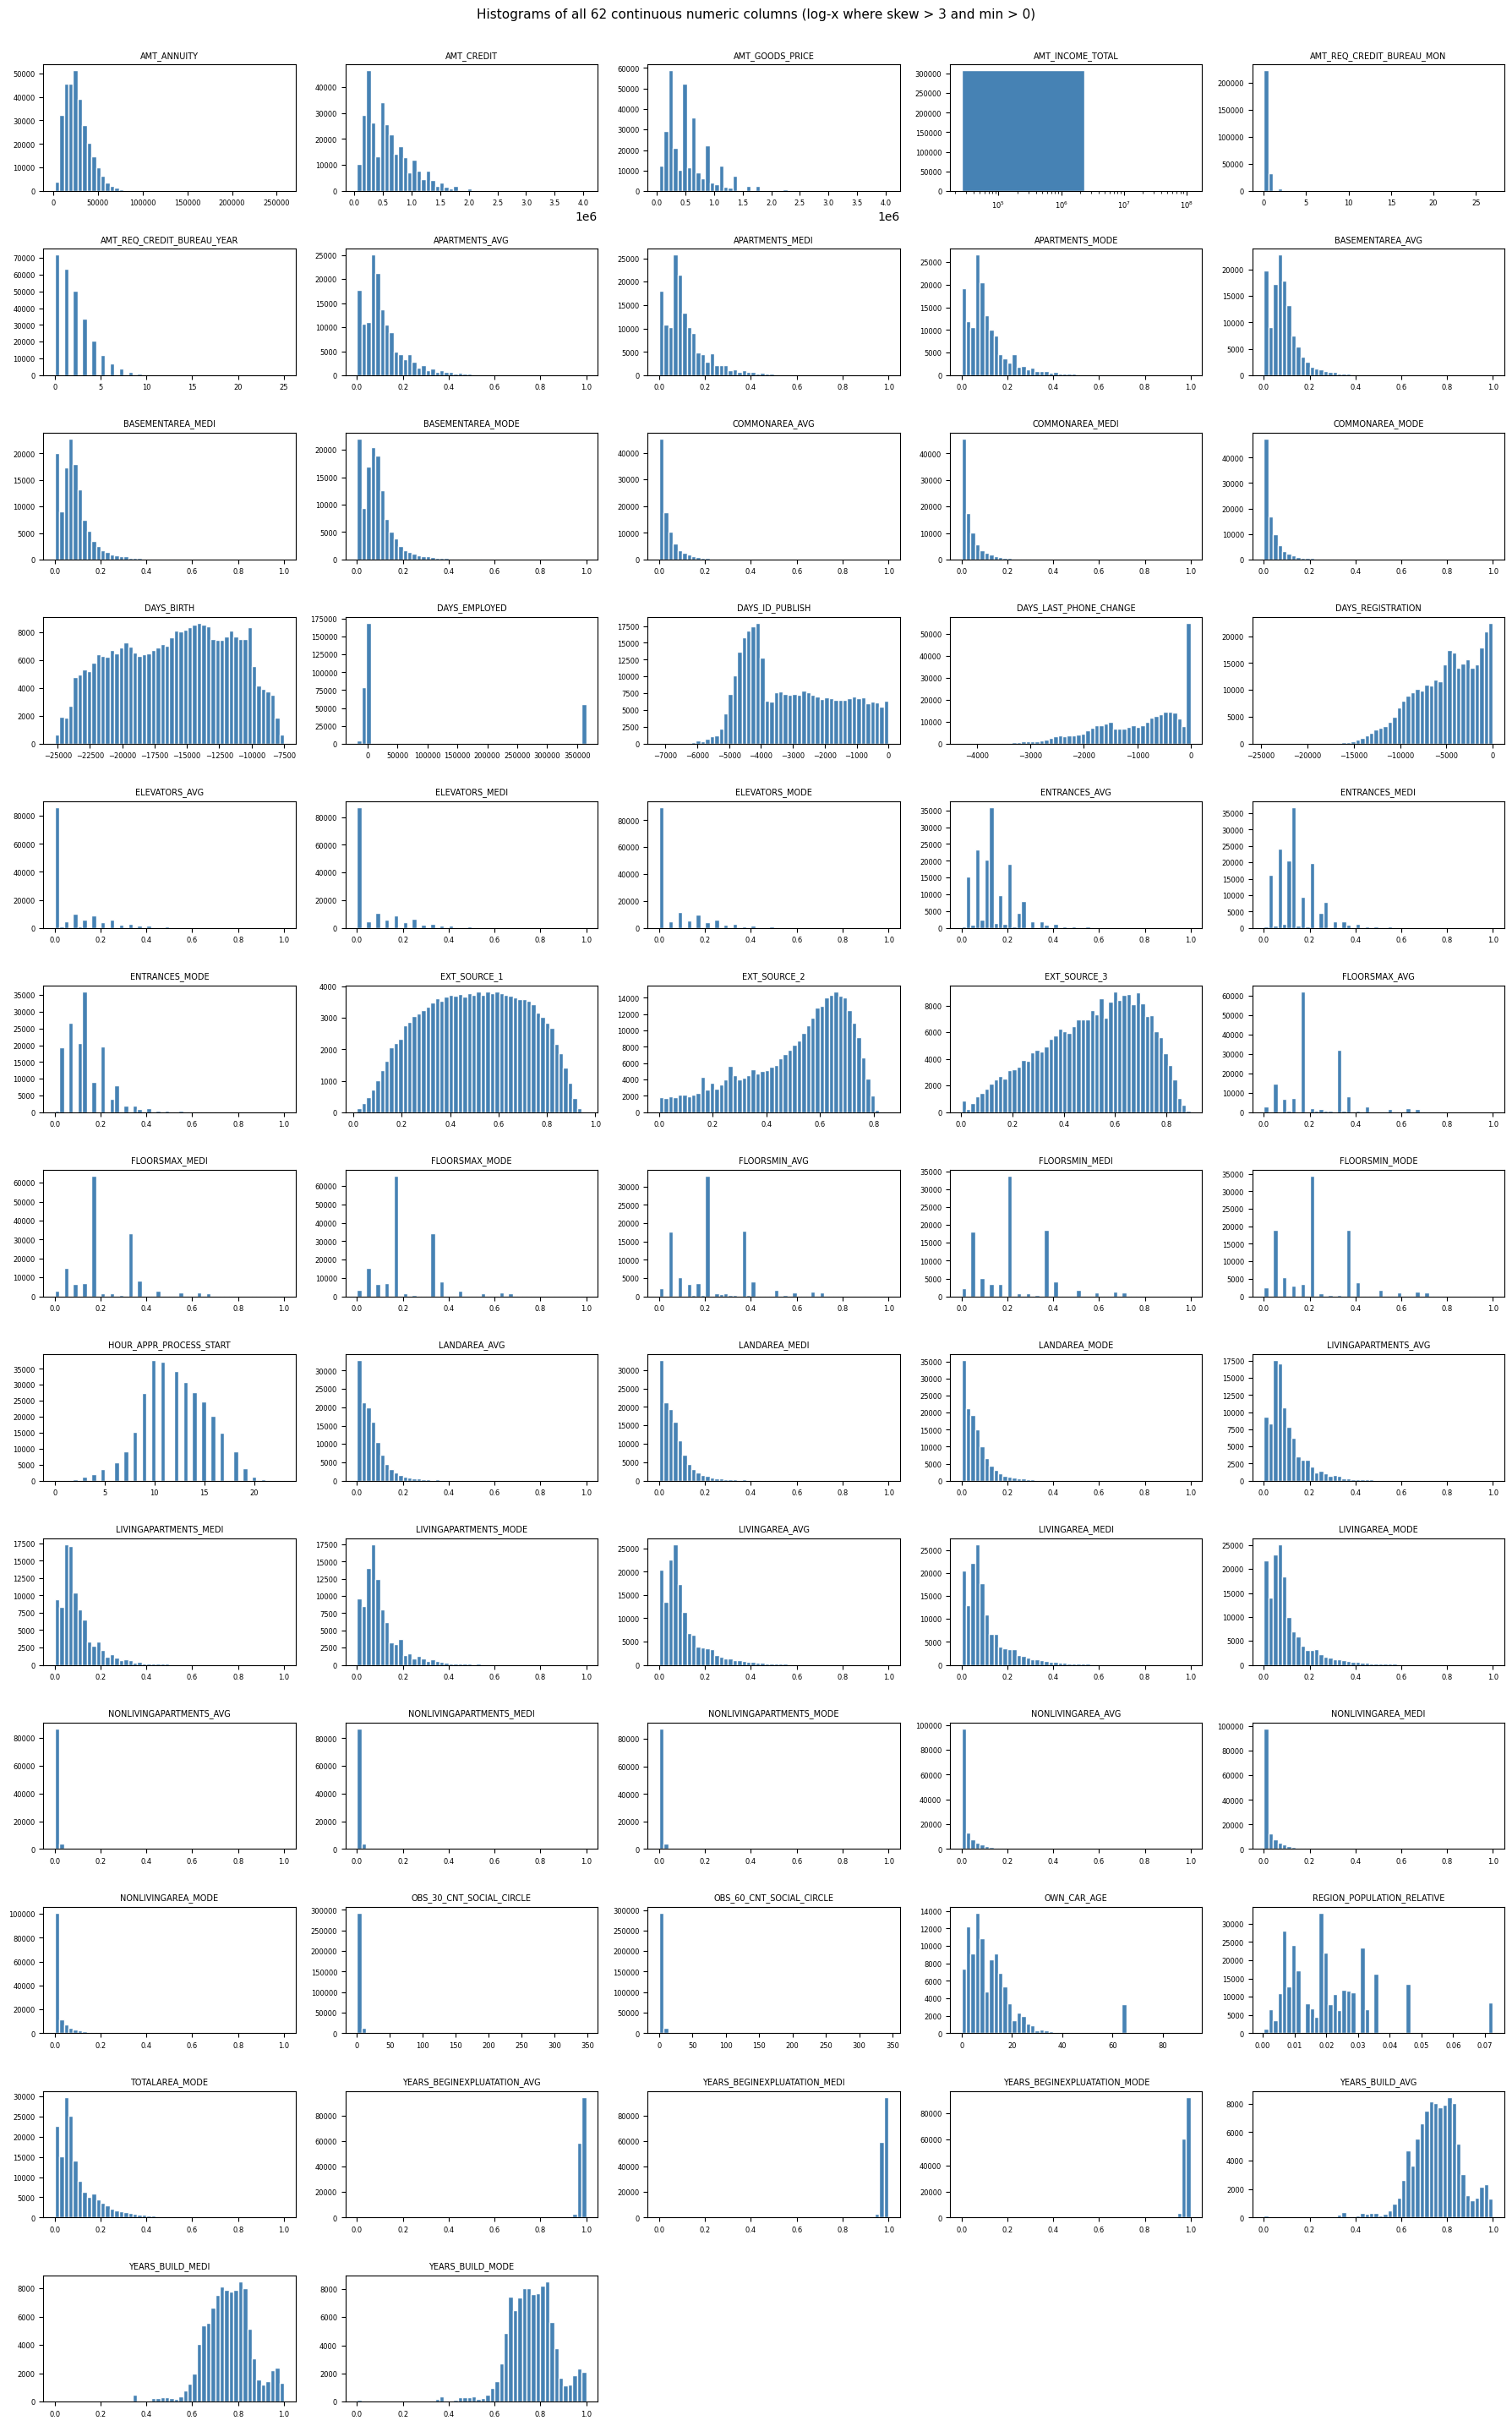

In [15]:
# histograms for every continuous numeric column.
# heavily right-skewed columns (skew > 3) that are strictly positive get a log-scale x-axis, which makes the shape easier to see.

cols = sorted(true_continuous_cols)

# figure out how many rows of 5 plots we need
ncols = 5
nrows = (len(cols) + ncols - 1) // ncols

# build the grid and flatten so we can loop with a single index
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.2))
axes = axes.flatten()

# one histogram per column
for i, col in enumerate(cols):
    s = df[col].dropna()
    ax = axes[i]

    # plot the histogram (same call regardless of scale)
    ax.hist(s, bins=50, color="steelblue", edgecolor="white")

    # switch to log-x only if strictly positive and heavily right-skewed
    if s.min() > 0 and s.skew() > 3:
        ax.set_xscale("log")

    ax.set_title(col, fontsize=7)
    ax.tick_params(axis="both", labelsize=6)

# hide any leftover empty subplots in the last row
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Histograms of all {len(cols)} continuous numeric columns "
    f"(log-x where skew > 3 and min > 0)",
    y=1.002, fontsize=11,
)
plt.tight_layout()
plt.show()

A few things stand out from the distributions.

- `DAYS_EMPLOYED` has a weird spike near 365,000. That is the sentinel 365243 for unemployed people, not a real value. We will turn it into NaN and add a flag column.

- `AMT_INCOME_TOTAL` is destroyed by outliers, the histogram is basically one block going up to 10⁸. We will winsorize at the 99th percentile before scaling.

- All the `DAYS_*` columns are negative because they count backwards from the application date. Not a bug, but we will flip them or convert to years.

- `EXT_SOURCE_1/2/3` look clean and well spread in [0, 1]. These are usually the strongest predictors of default.

- The `_AVG / _MEDI / _MODE` triplets are basically duplicates of each other. We will revisit this in the missing-values audit in section 9, where we decide what to do with the whole building-features block.

- `YEARS_BEGINEXPLUATATION_*` is saturated at 1, almost no variation. Probably useless, candidate for dropping.

- `OWN_CAR_AGE` has a small spike at 65 that might be another sentinel. Check with `value_counts()` before scaling.

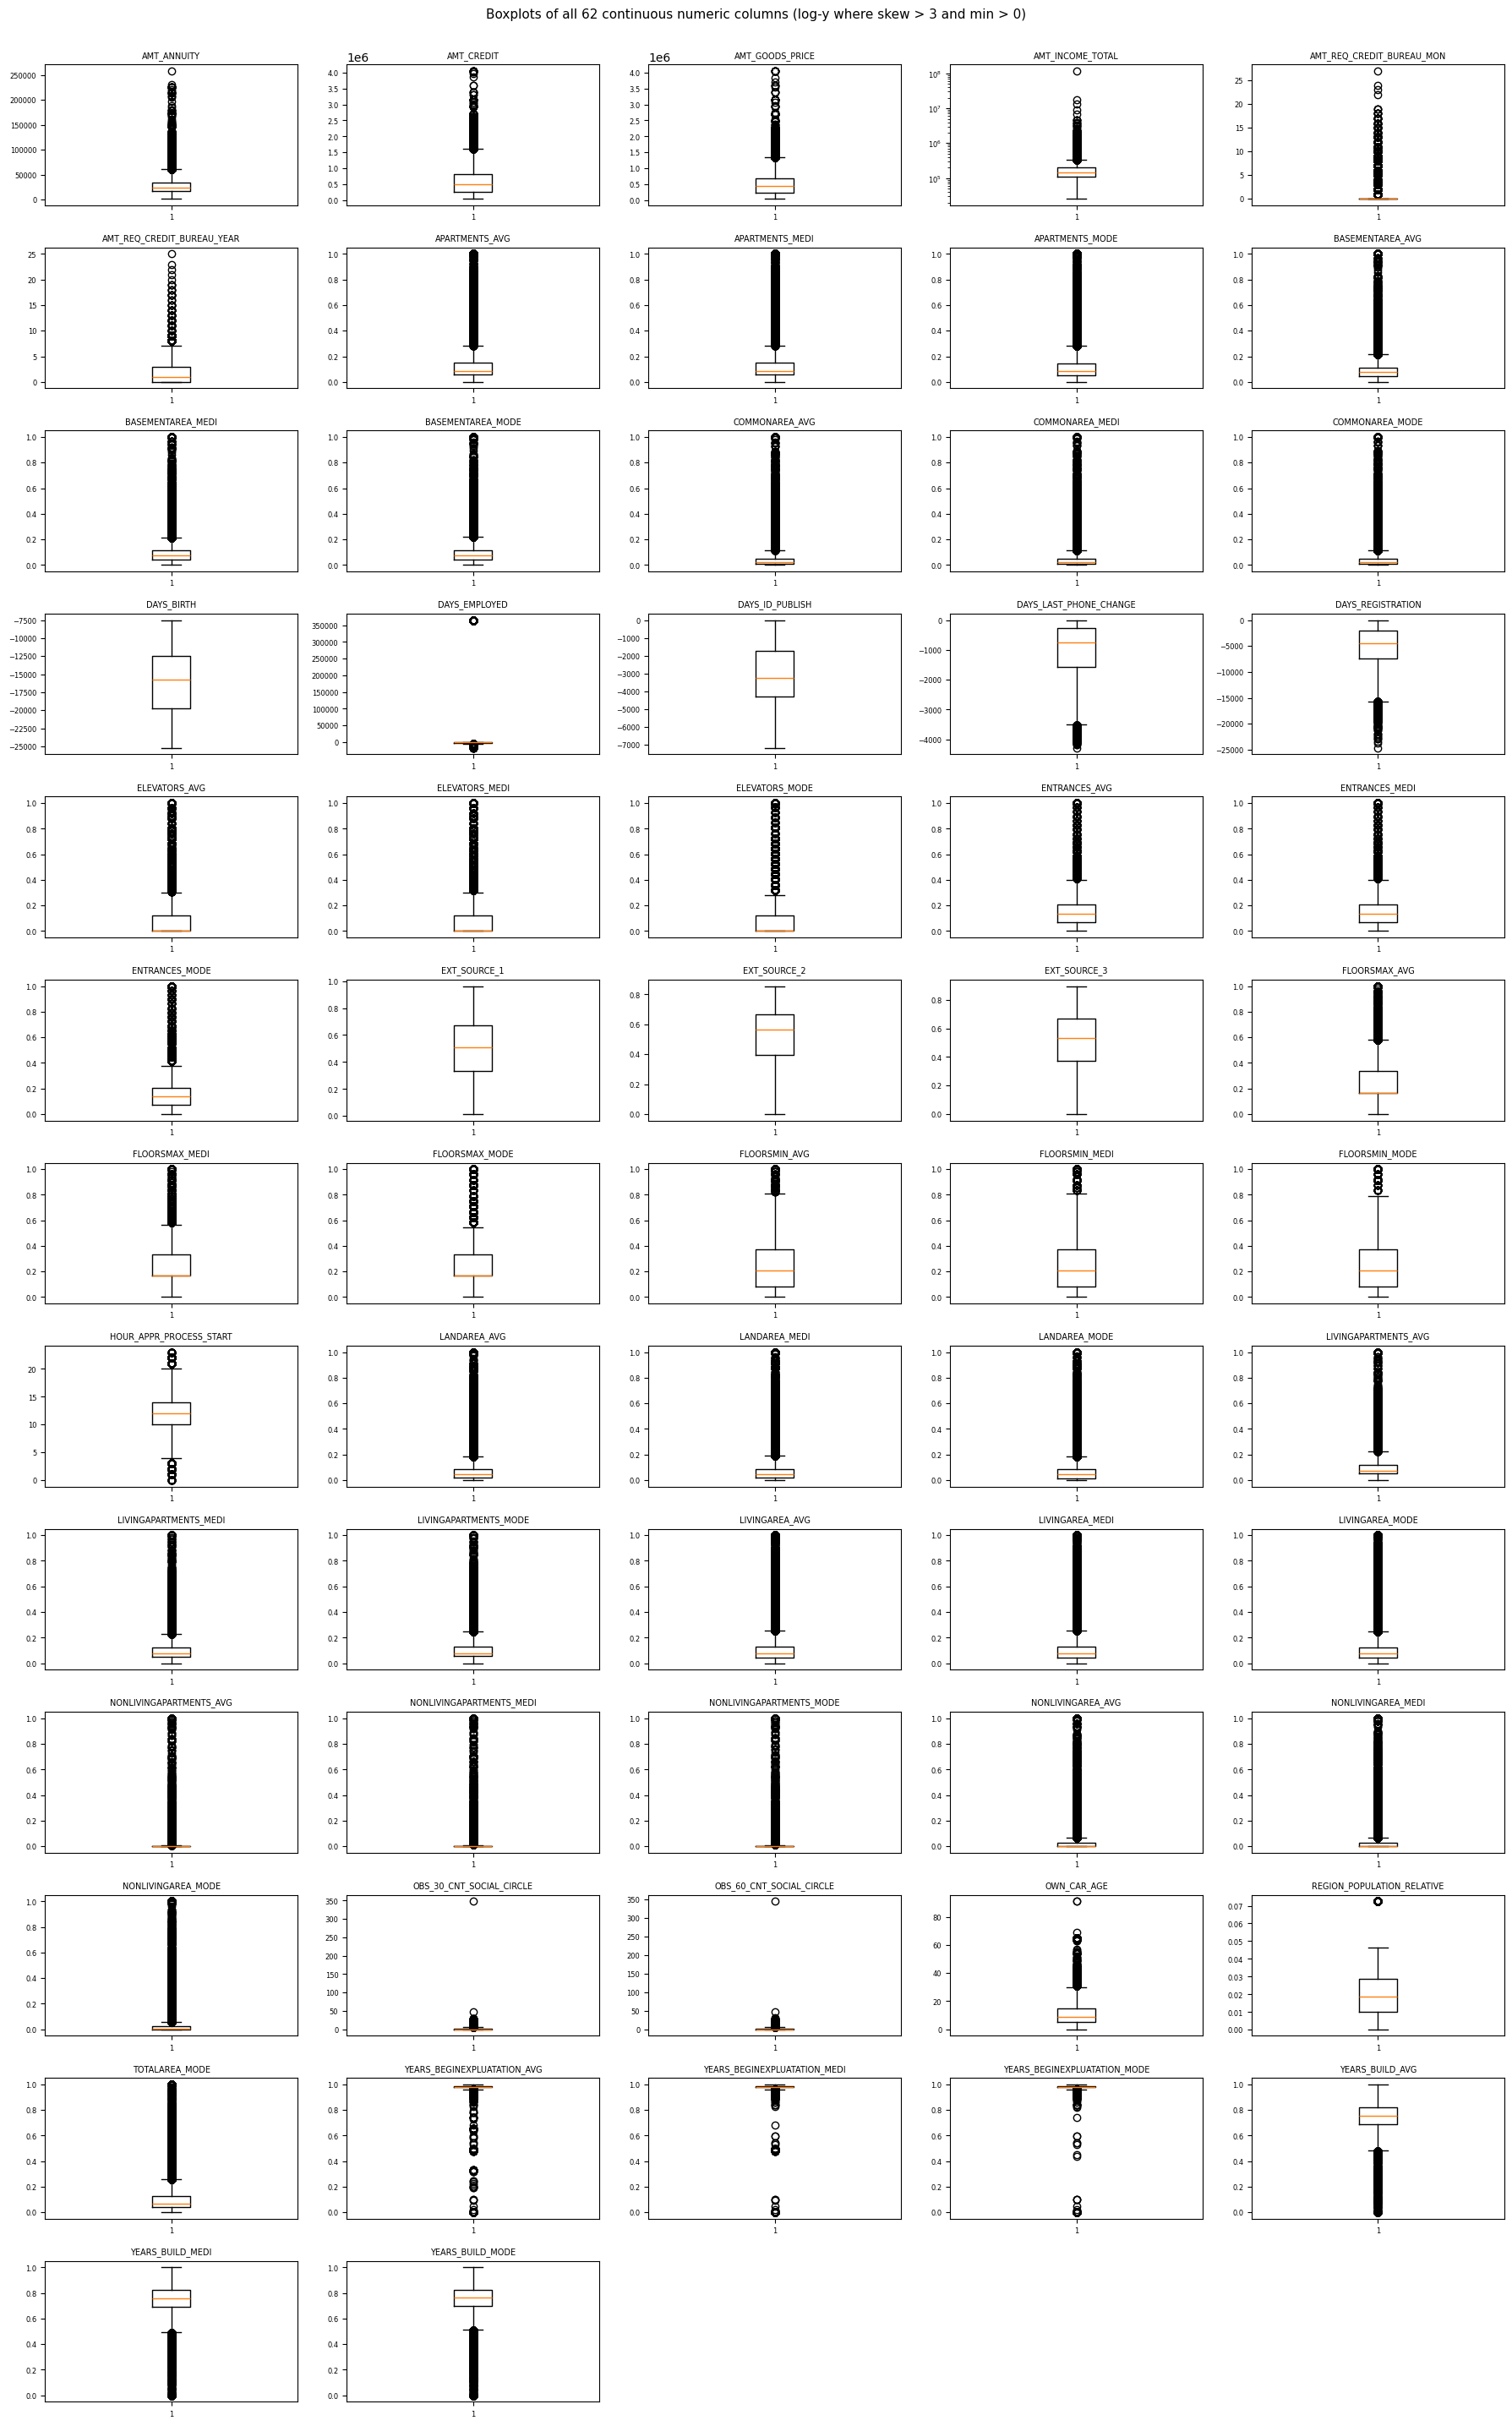

In [16]:
# boxplots for every continuous numeric column.
# same log-scale rule as the histograms: skew > 3 and min > 0 -> log-y axis.

cols = sorted(true_continuous_cols)

# figure out how many rows of 5 plots we need
ncols = 5
nrows = (len(cols) + ncols - 1) // ncols

# build the grid and flatten so we can loop with a single index
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.2))
axes = axes.flatten()

# one boxplot per column
for i, col in enumerate(cols):
    s = df[col].dropna()
    ax = axes[i]

    # draw the vertical boxplot
    ax.boxplot(s)

    # switch to log-y only if strictly positive and heavily right-skewed
    if s.min() > 0 and s.skew() > 3:
        ax.set_yscale("log")

    ax.set_title(col, fontsize=7)
    ax.tick_params(axis="both", labelsize=6)

# hide any leftover empty subplots in the last row
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Boxplots of all {len(cols)} continuous numeric columns "
    f"(log-y where skew > 3 and min > 0)",
    y=1.002, fontsize=11,
)
plt.tight_layout()
plt.show()

The boxplots confirm what the histograms already showed, just sharper.

- `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_GOODS_PRICE` and `AMT_ANNUITY` all have huge upper tails of outliers. Winsorizing at the 99th percentile in Phase 2 should fix this.

- `DAYS_EMPLOYED` is the cleanest case, the box is squashed near 0 and one isolated point sits at 365,000. That single point is the sentinel hiding a NaN.

- `OBS_30_CNT_SOCIAL_CIRCLE` and `OBS_60_CNT_SOCIAL_CIRCLE` show one extreme outlier around 350 while the rest of the data sits near 0. Probably another sentinel or a data error, we will check it with `value_counts()`.

- `OWN_CAR_AGE` confirms the spike around 65 we saw in the histograms.

- The building features (`APARTMENTS_*`, `BASEMENTAREA_*`, `LIVINGAREA_*`, `COMMONAREA_*`, `NONLIVING*_*`) are heavily zero-inflated with dense outlier clouds above. Same multicollinear `_AVG/_MEDI/_MODE` block we want to reduce.

- `EXT_SOURCE_1/2/3` have wide, well-centered boxes with no outliers. They look like the cleanest features in the dataset.

- `HOUR_APPR_PROCESS_START` is tight around midday with a few low-hour outliers, nothing strange.

### 4.2 Full sweep: all discrete numeric columns

Columns with 3..20 unique integer values plotted as bar counts.

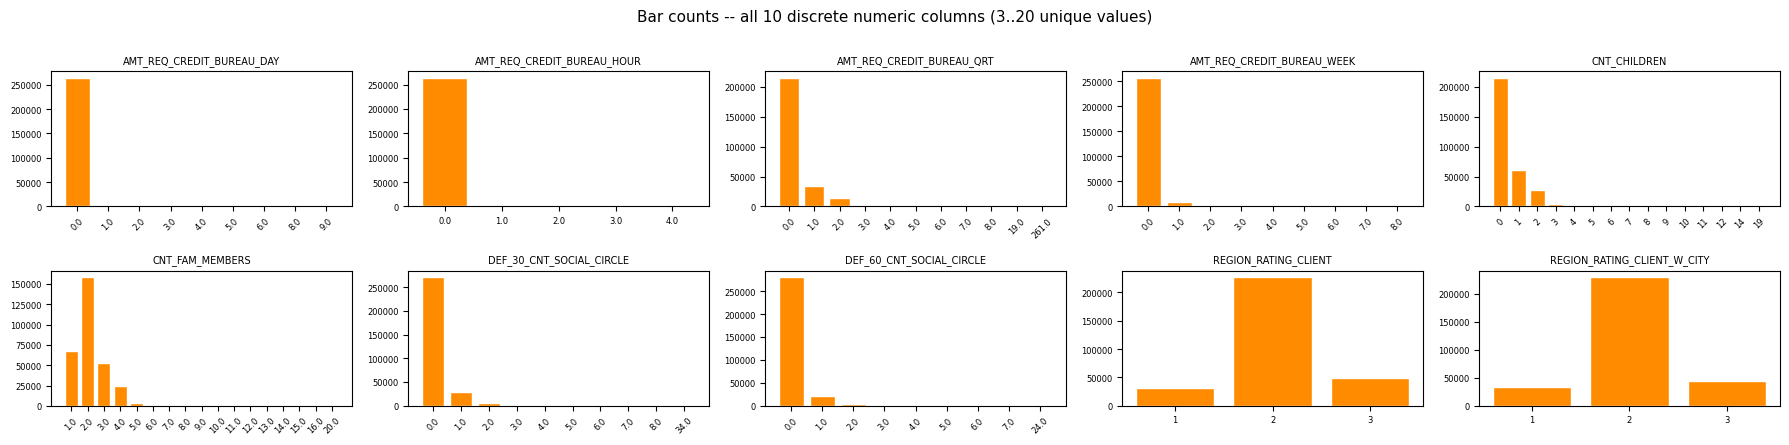

In [17]:
cols = sorted(discrete_cols)
ncols = 5
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 2.2))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes

for i, col in enumerate(cols):
    counts = df[col].value_counts().sort_index()
    ax = axes[i]
    ax.bar(counts.index.astype(str), counts.values,
           color="darkorange", edgecolor="white")
    ax.set_title(col, fontsize=7)
    ax.tick_params(axis="both", labelsize=6)
    # rotate x labels if there are many bars
    if len(counts) > 6:
        ax.tick_params(axis="x", rotation=45)

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Bar counts -- all {len(cols)} discrete numeric columns (3..20 unique values)",
    y=1.002, fontsize=11,
)
plt.tight_layout()
plt.show()

The discrete columns mostly behave as expected.

- The four `AMT_REQ_CREDIT_BUREAU_*` columns (day, hour, qrt, week) are almost entirely 0, meaning the vast majority of applicants had no credit bureau enquiries in those windows. Very low variance, probably weak predictors on their own but cheap to keep.

- `CNT_CHILDREN` and `CNT_FAM_MEMBERS` are right-skewed with most applicants having 0 to 2 children and 1 to 3 family members. A handful of extreme cases (10+ children) are visible, worth checking if they are real or data entry errors.

- `DEF_30_CNT_SOCIAL_CIRCLE` and `DEF_60_CNT_SOCIAL_CIRCLE` are heavily concentrated at 0, with the same pattern as the `OBS_*` versions. These might still carry signal because "any default in the social circle" could matter even if rare.

- `REGION_RATING_CLIENT` and `REGION_RATING_CLIENT_W_CITY` are clean 1/2/3 ordinals with most applicants in rating 2. We can treat them as ordinal directly without one-hot encoding.



### 4.3 All binary flag columns

All 0/1 columns ranked by % = 1. FLAG_MOBIL sits near 100%; some FLAG_DOCUMENT_* columns sit below 1%.

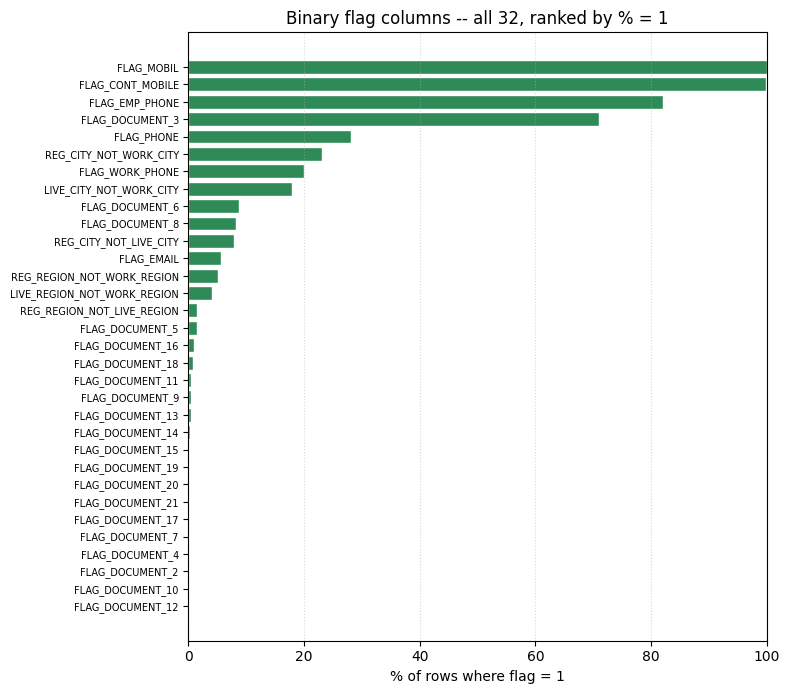

In [18]:
pct_ones = (
    df[binary_cols]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, max(6, len(pct_ones) * 0.22)))

# horizontal is a deliberate exception to the vertical house style --
# with 50+ binary columns, vertical labels overlap. same reasoning we
# used in the missingness overview.
y_positions = range(len(pct_ones))
ax.barh(y_positions, pct_ones.values, color="seagreen", edgecolor="white")
ax.set_yticks(list(y_positions))
ax.set_yticklabels(pct_ones.index, fontsize=7)
ax.invert_yaxis()  # highest % at top
ax.set_xlabel("% of rows where flag = 1")
ax.set_title(f"Binary flag columns -- all {len(pct_ones)}, ranked by % = 1")
ax.set_xlim(0, 100)
ax.grid(axis="x", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

The 32 binary flags split into three clear groups.

- Useless flags at 100%: `FLAG_MOBIL` and `FLAG_CONT_MOBILE` are 1 for everyone. Zero variance, they carry no information and we can drop them.

- Near-zero flags: most `FLAG_DOCUMENT_*` columns (4, 7, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20, 21) are 1 for less than 1% of applicants. Very low variance, but they could still carry weak signal in tree models. Candidate for grouping (for example "submitted any rare document") or dropping.

- Useful flags with real variance: `FLAG_EMP_PHONE` (~82%), `FLAG_DOCUMENT_3` (~71%), `FLAG_PHONE` (~28%), `REG_CITY_NOT_WORK_CITY` (~22%), `FLAG_WORK_PHONE` (~20%), `LIVE_CITY_NOT_WORK_CITY` (~18%) all have meaningful spread and likely carry signal. We will keep these as-is.

- The address mismatch flags (`REG_CITY_NOT_WORK_CITY`, `LIVE_CITY_NOT_WORK_CITY`, `REG_REGION_NOT_*`) are interesting because they capture mobility/instability, which is often correlated with credit risk.

### 4.4 Skewness ranking

continuous columns ranked by absolute skew, binary columns excluded.

In [19]:
# skewness is analytically meaningless on binary columns: a 99/1 split
# produces a huge number that tells you nothing about a tail. drop anything
# with <= 2 unique values before ranking.
nunique = df[numeric_cols].nunique(dropna=True)
non_binary_cols = nunique[nunique > 2].index.tolist()

skew_values = df[non_binary_cols].skew()
skew_table = (
    pd.DataFrame({
        "feature": skew_values.index,
        "skewness": skew_values.values.round(3)
    })
    .assign(abs_skew=lambda x: x["skewness"].abs())
    .sort_values("abs_skew", ascending=False)
    .drop(columns="abs_skew")
    .reset_index(drop=True)
)
print(f"Ranking skewness on {len(non_binary_cols)} non-binary numeric columns "
      f"(excluded {len(numeric_cols) - len(non_binary_cols)} binary columns).")
display(skew_table.head(20))

Ranking skewness on 73 non-binary numeric columns (excluded 33 binary columns).


,feature,skewness
0,AMT_INCOME_TOTAL,391.560
1,AMT_REQ_CREDIT_BUREAU_QRT,134.366
2,AMT_REQ_CREDIT_BUREAU_DAY,27.044
3,NONLIVINGAPARTMENTS_MODE,16.252
4,NONLIVINGAPARTMENTS_MEDI,15.672
5,YEARS_BEGINEXPLUATATION_MEDI,-15.573
6,NONLIVINGAPARTMENTS_AVG,15.541
7,YEARS_BEGINEXPLUATATION_AVG,-15.515
8,YEARS_BEGINEXPLUATATION_MODE,-14.755
9,AMT_REQ_CREDIT_BUREAU_HOUR,14.534


Top 20 features by absolute skewness, sorted from worst to least bad.

- `AMT_INCOME_TOTAL` is by far the most skewed (391.6), driven by the same extreme outliers we saw in the boxplots. Confirms that winsorization is needed before scaling.

- The `AMT_REQ_CREDIT_BUREAU_*` columns (qrt, day, hour, week, mon) are highly skewed because they are almost all 0, as we saw in the discrete bar charts. Skewness here is just a side effect of the zero-inflation, not a separate problem.

- The `NONLIVINGAPARTMENTS_*` and `NONLIVINGAREA_*` triplets show extreme positive skew (15+), and `YEARS_BEGINEXPLUATATION_*` show extreme negative skew (-15) because of the saturation at 1.0. Same multicollinear building-features block we already plan to reduce.

- `OBS_30/60_CNT_SOCIAL_CIRCLE` skewness (~12) comes from the single ~350 outlier we spotted earlier. Once we cap or remove it the skewness should drop a lot.

- `COMMONAREA_*` triplet (skew ~5.5) is more zero-inflation in the same building block.


## 5. Univariate Categorical

we look at each categorical column on its own to spot dominant levels and rare categories.

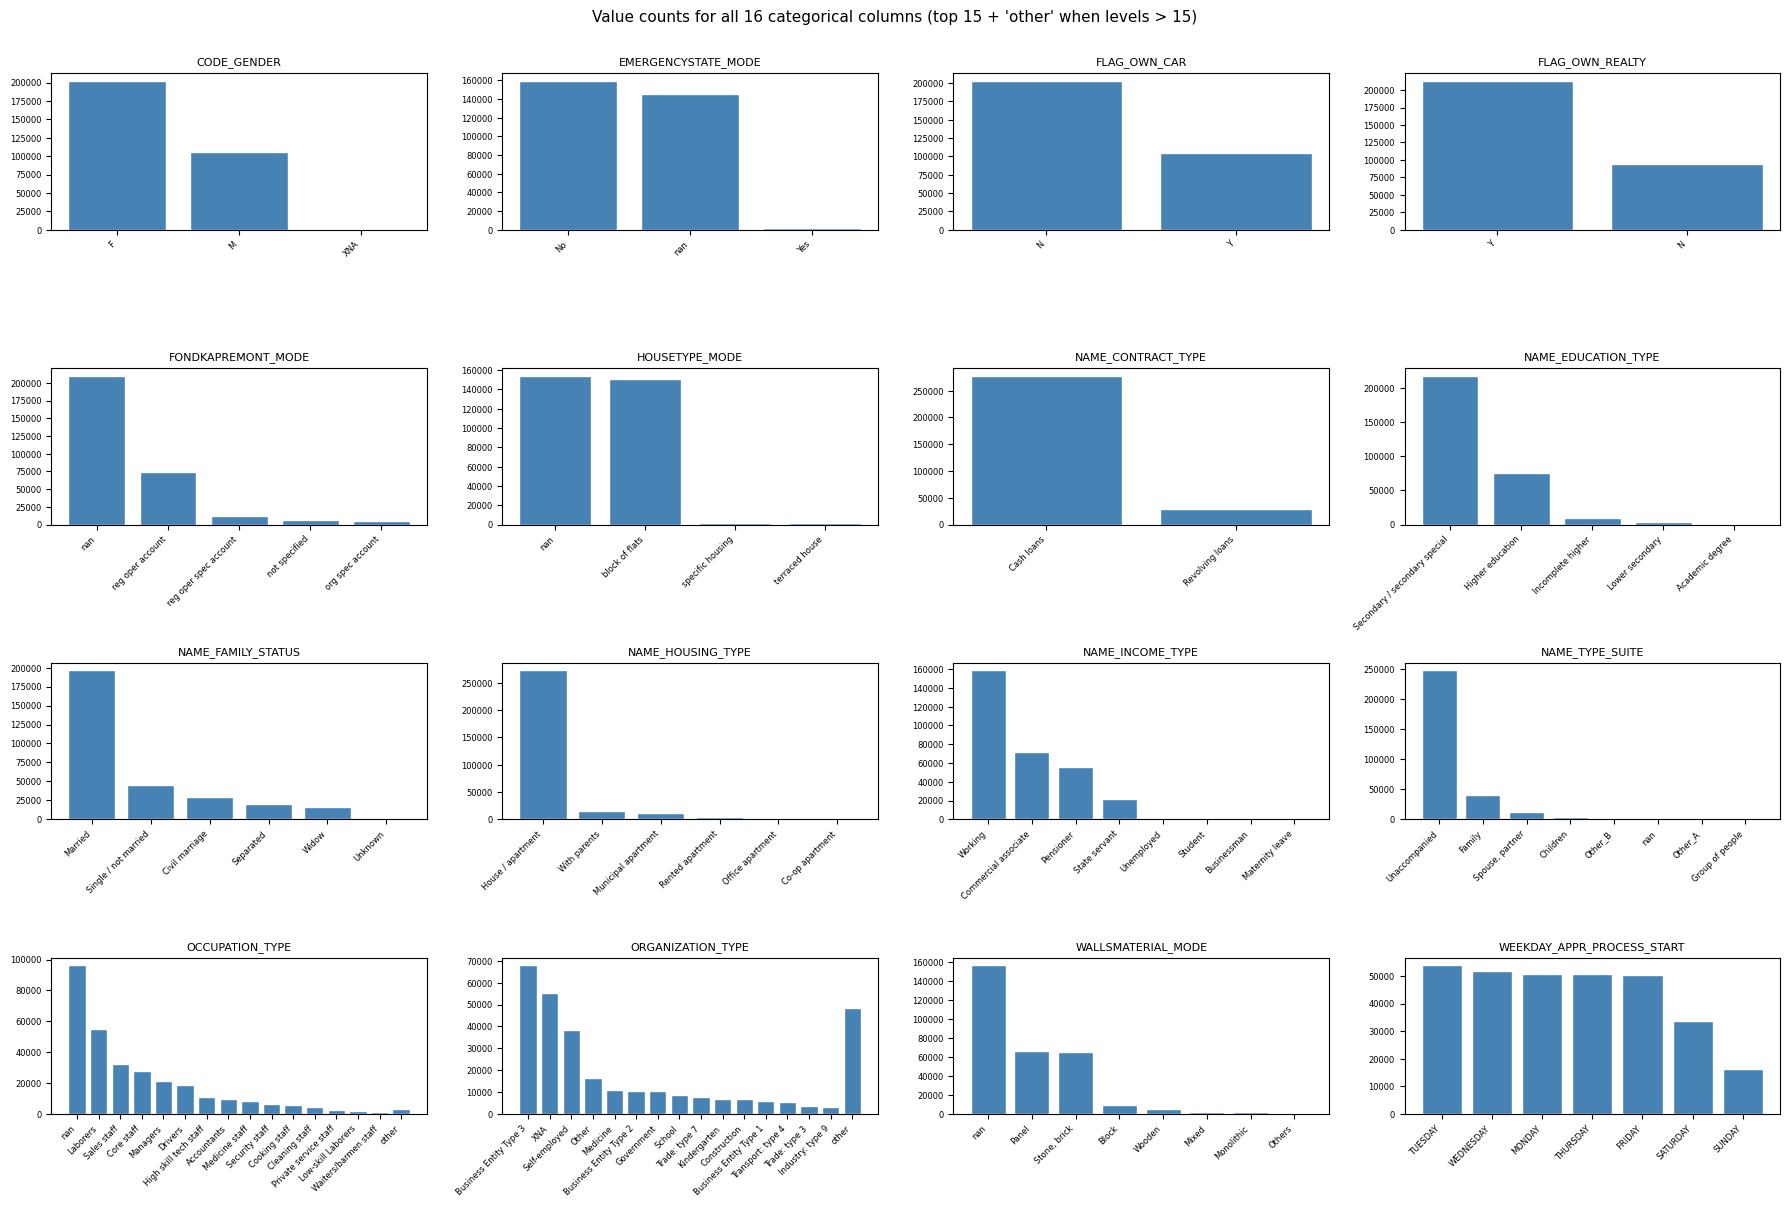

In [20]:
# bar counts for every categorical column.
# ORGANIZATION_TYPE has 58 levels, too many to plot readably, so for any
# column with more than 15 categories we show the top 15 plus an "other" bar.

cols = sorted(object_cols)

# figure out how many rows of 4 plots we need (categoricals need more width per plot than histograms)
ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

# build the grid and flatten so we can loop with a single index
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

# one bar chart per column
for i, col in enumerate(cols):
    vc = df[col].value_counts(dropna=False)
    ax = axes[i]

    # for high-cardinality columns, keep the top 15 and lump the rest into "other"
    if len(vc) > 15:
        top = vc.iloc[:15]
        other = pd.Series({"other": vc.iloc[15:].sum()})
        vc = pd.concat([top, other])

    ax.bar(range(len(vc)), vc.values, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=45, ha="right", fontsize=6)
    ax.set_title(col, fontsize=8)
    ax.tick_params(axis="y", labelsize=6)

# hide any leftover empty subplots in the last row
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Value counts for all {len(cols)} categorical columns "
    f"(top 15 + 'other' when levels > 15)",
    y=1.002, fontsize=11,
)
plt.tight_layout()
plt.show()

The categorical columns confirm a few things and surface a couple of new ones.

- `CODE_GENDER` has the documented `XNA` category with very few rows (4 cases). We will drop or merge these into the majority class in Phase 2.

- `NAME_EDUCATION_TYPE` has the natural ordering noted in the data dictionary (Lower secondary < Secondary < Incomplete higher < Higher education < Academic degree). We will encode it as ordinal instead of one-hot.

- `ORGANIZATION_TYPE` has the 58-category explosion we expected. Top categories are Business Entity Type 3, XNA, Self-employed. The long tail of small categories will need grouping into "Other" before one-hot encoding, otherwise we get 58 extra columns of mostly zeros.

- `OCCUPATION_TYPE`, `FONDKAPREMONT_MODE`, `HOUSETYPE_MODE`, `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE` and `NAME_TYPE_SUITE` all have `nan` as a top category. Missingness here is not random and may itself carry signal, so we will impute with a literal "Missing" category instead of dropping or mode-filling.

- `NAME_INCOME_TYPE` has very rare categories (Student, Businessman, Maternity leave, Unemployed) with only a handful of rows each. Group into "Other" before encoding.

- `NAME_FAMILY_STATUS` has a tiny "Unknown" category that we should also fold into the majority or drop.

- `WEEKDAY_APPR_PROCESS_START` shows the expected weekday pattern (more applications Mon-Fri, less on weekends). Probably weak predictor but cheap to keep.

- `NAME_CONTRACT_TYPE` is mostly Cash loans (~90%) vs Revolving loans. Useful binary feature.

## 6. Bivariate

we compare each feature against `TARGET` to see which ones look predictive.

For categorical features we plot the default rate per category; for continuous features we compare the distribution for `TARGET=0` vs `TARGET=1`. This gives a first ranking of which features look predictive and a first signal of subgroup differences in default rate.

### 6.1 Default rate by categorical subgroup

default rate per category for six categoricals tied to demographics and loan type.

For each of these six categoricals we compute how many applicants fall in each category (`n`) and what share defaulted (`default_rate`). We pick these six because they are the ones most relevant for the report: three demographics tied to fairness (`CODE_GENDER`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`) and three loan / lifestyle descriptors (`NAME_CONTRACT_TYPE`, `NAME_INCOME_TYPE`, `NAME_HOUSING_TYPE`).

In [21]:
# six categoricals worth looking at: three demographics (RQ3) + three loan/lifestyle
subgroup_cols = [
    "CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS",
    "NAME_CONTRACT_TYPE", "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE",
]

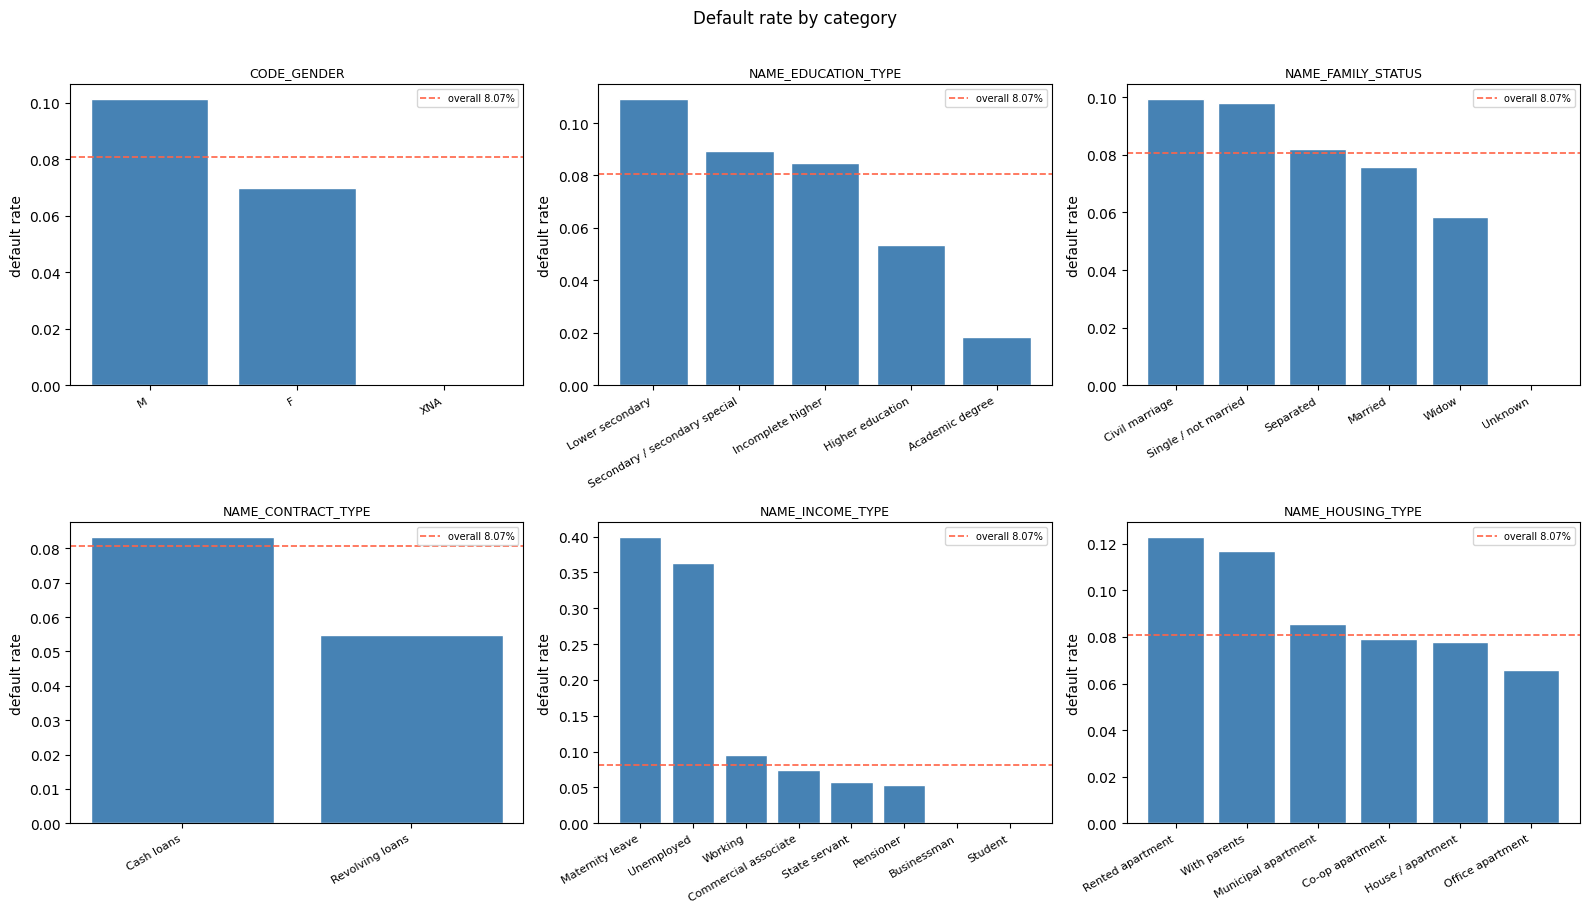

In [22]:
# default rate per category, one subplot per feature.
# red dashed line shows the overall default rate as a reference.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(subgroup_cols):
    # share of defaulters within each category, sorted highest first
    dr = df.groupby(col)["TARGET"].mean().sort_values(ascending=False)

    ax = axes[i]
    ax.bar(range(len(dr)), dr.values, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(dr)))
    ax.set_xticklabels(dr.index, rotation=30, ha="right", fontsize=8)

    # reference line: dataset-wide default rate
    ax.axhline(default_rate, color="tomato", linestyle="--", linewidth=1.2,
               label=f"overall {default_rate:.2%}")

    ax.set_ylabel("default rate")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Default rate by category", y=1.01)
plt.tight_layout()
plt.show()

This is the first chart that directly shows which categories carry signal for default. Overall default rate is 8.07%, anything far from that line is a real differentiator.

- `CODE_GENDER`: men default at ~10.1%, women at ~7.0%. Real gap of roughly 3 percentage points. Important for RQ3 fairness analysis, this is exactly the kind of disparity we will need to discuss.

- `NAME_EDUCATION_TYPE`: clean monotonic pattern. Lower secondary defaults at ~11%, Academic degree at <2%. Confirms the natural ordering and strongly justifies ordinal encoding.

- `NAME_FAMILY_STATUS`: Civil marriage and Single default the most (~10%), Widow the least (~6%). Decent spread but smaller than education.

- `NAME_CONTRACT_TYPE`: Cash loans default at ~8%, Revolving loans at ~5.5%. Useful binary signal.

- `NAME_INCOME_TYPE`: massive gap. Maternity leave (~40%) and Unemployed (~36%) default at huge rates, but these are tiny categories (handful of rows each), so the estimates are noisy. Working/Commercial associate sit near average. Pensioners and Students default the least. This is a clear case where rare categories carry strong signal but small samples, exactly why we need to think carefully before grouping them into "Other".

- `NAME_HOUSING_TYPE`: Rented apartment and With parents default at ~12%, Office apartment at ~6.5%. Housing instability tracking with credit risk.

### 6.2 Default rate by age bracket

default rate per age decade; age is the second protected attribute flagged in the plan.

`DAYS_BIRTH` is stored as a negative number of days relative to the application date. We convert to years (`age = -DAYS_BIRTH / 365.25`) and bin by decade so we can treat age as a categorical subgroup, the same way we handled the six columns in 6.1.

In [23]:
# DAYS_BIRTH is stored as negative days (e.g. -10000 for ~27 years old).
# multiply by -1 and divide by 365.25 (accounts for leap years) to get age in years.
age_years = -df["DAYS_BIRTH"] / 365.25

# bin applicants into decade brackets so we can treat age as a categorical subgroup.
# pd.cut is right-inclusive by default, so someone aged exactly 30.0 goes into the 20-30 bin.
age_bins = pd.cut(
    age_years,
    bins=[20, 30, 40, 50, 60, 70],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70"],
)

# quick sanity check that the conversion looks right (mean around 44, min ~20, max ~70)
print("age summary (years):")
age_years.describe().round(1)

age summary (years):


,DAYS_BIRTH
count,307511.0
mean,43.9
std,11.9
min,20.5
25%,34.0
50%,43.1
75%,53.9
max,69.1


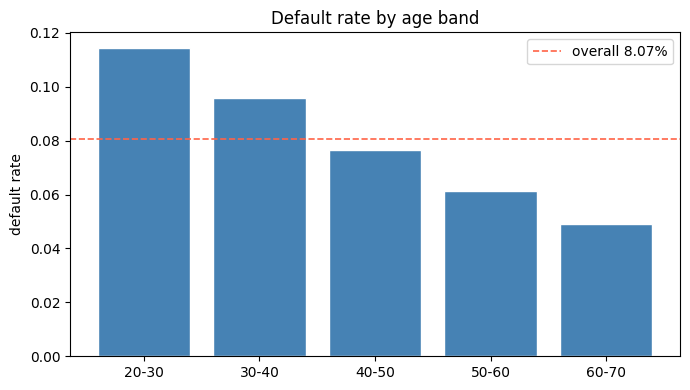

In [24]:
# default rate per age bracket, computed inline from age_bins
age_dr = df.groupby(age_bins, observed=True)["TARGET"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(age_dr)), age_dr.values, color="steelblue", edgecolor="white")
ax.set_xticks(range(len(age_dr)))
ax.set_xticklabels(age_dr.index.tolist(), rotation=0)

# reference line: dataset-wide default rate
ax.axhline(default_rate, color="tomato", linestyle="--", linewidth=1.2,
           label=f"overall {default_rate:.2%}")

ax.set_ylabel("default rate")
ax.set_title("Default rate by age band")
ax.legend()
plt.tight_layout()
plt.show()

Default rate by age band shows a clean monotonic pattern. Younger applicants (20-30) default at ~11.4%, older applicants (60-70) at ~4.9%. The rate drops steadily with age across all five bands.

This is a strong, interpretable signal and matches what we would expect from credit risk literature: younger borrowers tend to have shorter credit histories, less stable income, and higher default rates.

Important for RQ3 fairness: age is another protected attribute under the EU AI Act, so we will need to slice model performance by these same age bands in Phase 6 and check whether the model treats younger applicants disproportionately. The fact that the underlying default rate genuinely differs by age makes this analysis more nuanced, real risk differences vs unfair model behavior are not the same thing.

### 6.3 Default rate by income band

default rate per fixed-width income band on a round-number grid.

We split `AMT_INCOME_TOTAL` into fixed-width bands rather than quantiles. Edges follow the round-number grid 0-100k, 100-125k, ..., 350-500k, 500k+. Fixed bands show the *shape* of the risk curve at interpretable income levels (e.g. "what happens around 200k?"), which quantile binning would flatten since each quartile would just hold 25% by construction. The top band is left open-ended (500k+) to absorb the extreme-income outliers flagged in the data dictionary without creating sparse singleton bins in the tail.

In [25]:
# fixed-width income bands on a round-number grid.
# top band is open-ended so extreme incomes (e.g. the 117M outlier) don't create 1-applicant bins.
income_edges = [0, 100_000, 125_000, 150_000, 175_000, 200_000,
                250_000, 350_000, 500_000, float("inf")]
income_labels = ["0-100k", "100-125k", "125-150k", "150-175k",
                 "175-200k", "200-250k", "250-350k", "350-500k",
                 "500k+"]

# right=False makes bins left-inclusive, so 100k goes into "100-125k" not "0-100k"
income_band = pd.cut(df["AMT_INCOME_TOTAL"], bins=income_edges,
                     labels=income_labels, right=False, include_lowest=True)

# count applicants and compute default rate per band
income_dr = (
    df.groupby(income_band, observed=True)["TARGET"]
    .agg(n="count", default_rate="mean")
    .round(4)
)
display(income_dr)

,n,default_rate
AMT_INCOME_TOTAL,,
0-100k,63698,0.0820
100-125k,43701,0.0879
125-150k,47890,0.0846
150-175k,34663,0.0859
175-200k,29644,0.0828
200-250k,48137,0.0774
250-350k,25913,0.0671
350-500k,11163,0.0593
500k+,2702,0.0540


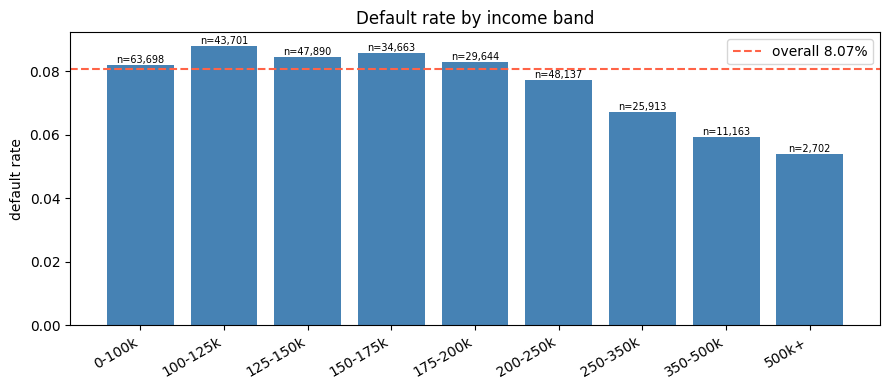

In [26]:
# bar chart of default rate per income band, with sample size above each bar
plt.figure(figsize=(9, 4))
plt.bar(range(len(income_dr)), income_dr["default_rate"], color="steelblue")

# use the band labels as x-tick labels
plt.xticks(range(len(income_dr)), income_dr.index, rotation=30, ha="right")

# reference line: dataset-wide default rate
plt.axhline(default_rate, color="tomato", linestyle="--",
            label=f"overall {default_rate:.2%}")

# annotate each bar with n so the reader sees which bands have few applicants
for i, (rate, n) in enumerate(zip(income_dr["default_rate"], income_dr["n"])):
    plt.text(i, rate, f"n={n:,}", ha="center", va="bottom", fontsize=7)

plt.ylabel("default rate")
plt.title("Default rate by income band")
plt.legend()
plt.tight_layout()
plt.show()

Default rate by income band is flatter than expected. The bottom five bands (0-200k) all sit around 8-9%, basically on the overall average. The drop only starts above 200k, reaching ~5.4% in the 500k+ band.

Income alone is not a strong separator in the low-to-mid range, which is interesting. It suggests that for most applicants other features (education, age, external scores) matter more than raw income for predicting default.

The sample sizes (n= annotations) are healthy across all bands, so the pattern is reliable and not driven by noise in small buckets.

In [27]:
# 5000-row sample used in the pairplots for readability
sample5k = df.sample(5000, random_state=SEED)

### 6.4 Pairwise scatters across feature groups

Building on the correlation ranking computed in section 7, we plot two pairwise grids coloured by `TARGET`.

The two groups are motivated by findings from the correlation matrix:

- **Top predictors group** (`EXT_SOURCE_1/2/3`, age): the three external credit scores sit at the top of the correlation-with-target ranking (|r| ≈ 0.15-0.18, the largest in the matrix), and the age gradient in 6.2 made age a natural fourth. We plot them pairwise to see where defaulters concentrate in the 2D projections.
- **Money features group** (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`): none of these top the correlation ranking, but they are the four amount columns that feed the engineered ratio features in preprocessing (`CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `CREDIT_TERM`, `credit_to_goods`). We plot them pairwise to see the structural relationships that motivate the ratios.

Both grids use a 5000-row subsample for readability.

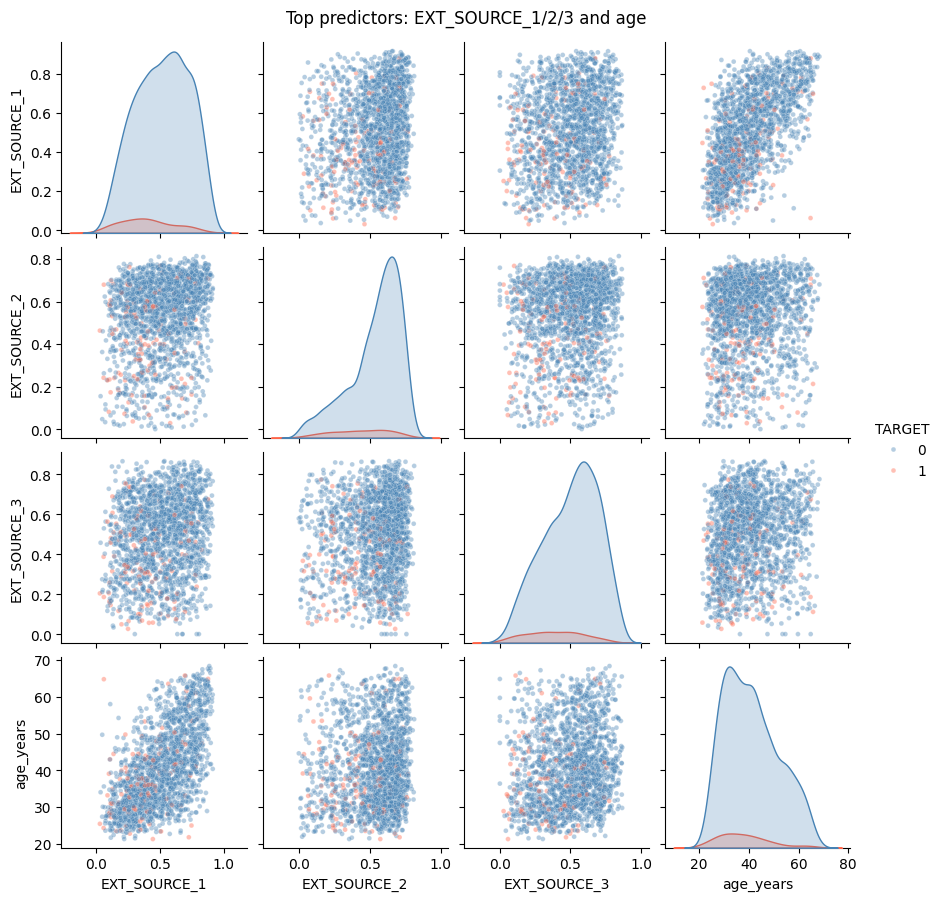

In [28]:
# top-predictors pairplot: the 3 external scores + age
# age_years derived from DAYS_BIRTH for readability
top_pred = sample5k[["TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].copy()
top_pred["age_years"] = -sample5k["DAYS_BIRTH"] / 365.25

sns.pairplot(
    top_pred.dropna(),
    hue="TARGET",
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.4, "s": 12},
    diag_kind="kde",
    height=2.2,
)
plt.suptitle("Top predictors: EXT_SOURCE_1/2/3 and age", y=1.02)
plt.show()

- The `EXT_SOURCE_*` off-diagonals show visible class separation:
  defaulters concentrate in the low-score region across every pair of
  external scores. This is the clearest single piece of evidence that
  these three features will dominate feature importance in the models.
- The `age_years` pairs tilt slightly, with defaulters skewing toward
  younger applicants. Combined with low external scores, the
  "young + low score" corner is the highest-risk region.
- Diagonal densities show the class imbalance clearly: the `TARGET=1`
  curve is always smaller (~8% of the sample), and for the three
  external scores it is visibly shifted left (toward lower values).

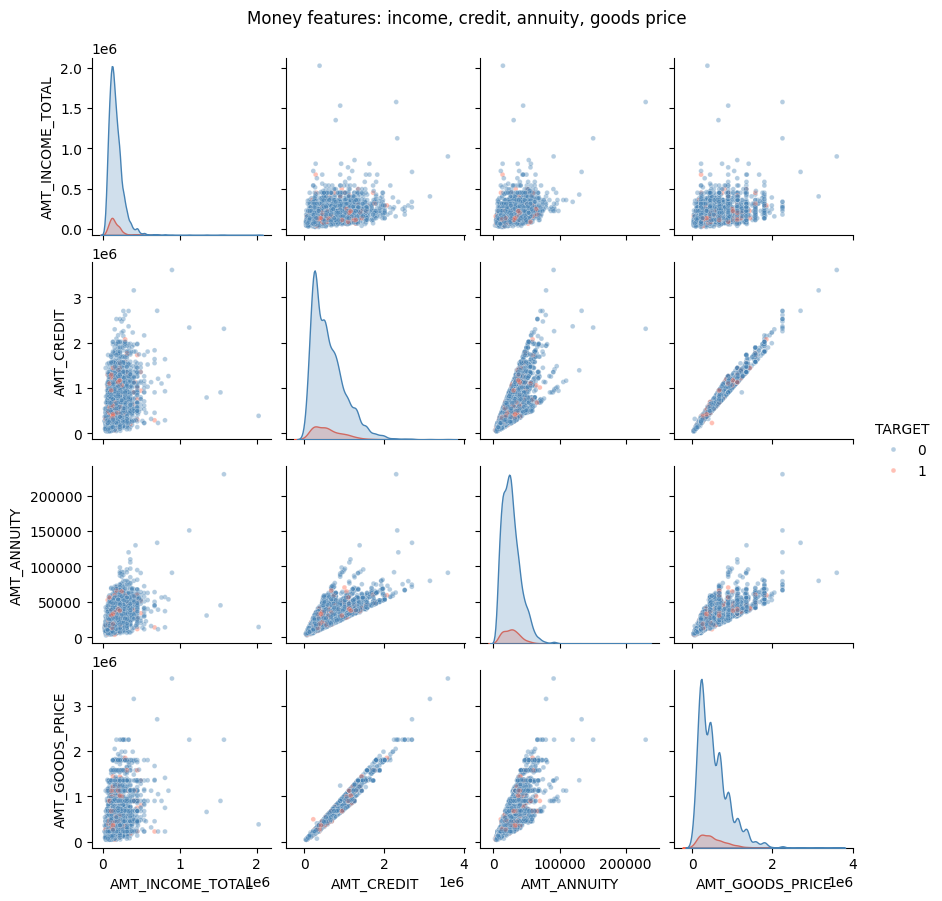

In [29]:
# money-features pairplot: the four amount columns that feed the engineered ratios
money = sample5k[["TARGET", "AMT_INCOME_TOTAL", "AMT_CREDIT",
                  "AMT_ANNUITY", "AMT_GOODS_PRICE"]]

sns.pairplot(
    money.dropna(),
    hue="TARGET",
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.4, "s": 12},
    diag_kind="kde",
    height=2.2,
)
plt.suptitle("Money features: income, credit, annuity, goods price", y=1.02)
plt.show()

- `AMT_CREDIT` vs `AMT_ANNUITY` and `AMT_CREDIT` vs `AMT_GOODS_PRICE`
  trace tight diagonals, confirming the near-linear structure between
  these pairs. The diagonal is the expected relationship, and the
  deviation from it is exactly what the engineered ratios
  (`CREDIT_TERM`, `credit_to_goods`) capture.
- `AMT_INCOME_TOTAL` against any of the other three shows a wide
  noisy cloud with extreme-income outliers in the tail and no visible
  class separation. Raw income alone does not predict default.
- Defaulters and non-defaulters are intermixed throughout every
  off-diagonal pair in this group, which is why the engineered
  ratios add signal that the raw columns don't carry on their own.

## 7. Correlation Heatmap

Pearson correlation on the top-20 most TARGET-correlated numeric features.

In [30]:
# rank numeric features by strength of their linear association with TARGET
# we exclude the ID column and TARGET itself
excluded = {"SK_ID_CURR", "TARGET"}
feature_cols = [c for c in numeric_cols if c not in excluded]

# correlation of each feature with TARGET, sorted by absolute value (strongest first)
corr_with_target = df[feature_cols].corrwith(df["TARGET"]).abs().sort_values(ascending=False)
top20 = corr_with_target.head(20).index.tolist()

# correlation matrix among top 20 features + TARGET
# keeping TARGET in lets us read off each feature's sign vs the target
corr_matrix = df[top20 + ["TARGET"]].corr()

# show the ranking so readers see what made the cut
# print("Top 20 features by |correlation with TARGET|:")
# print(corr_with_target.head(20).round(4).to_string())

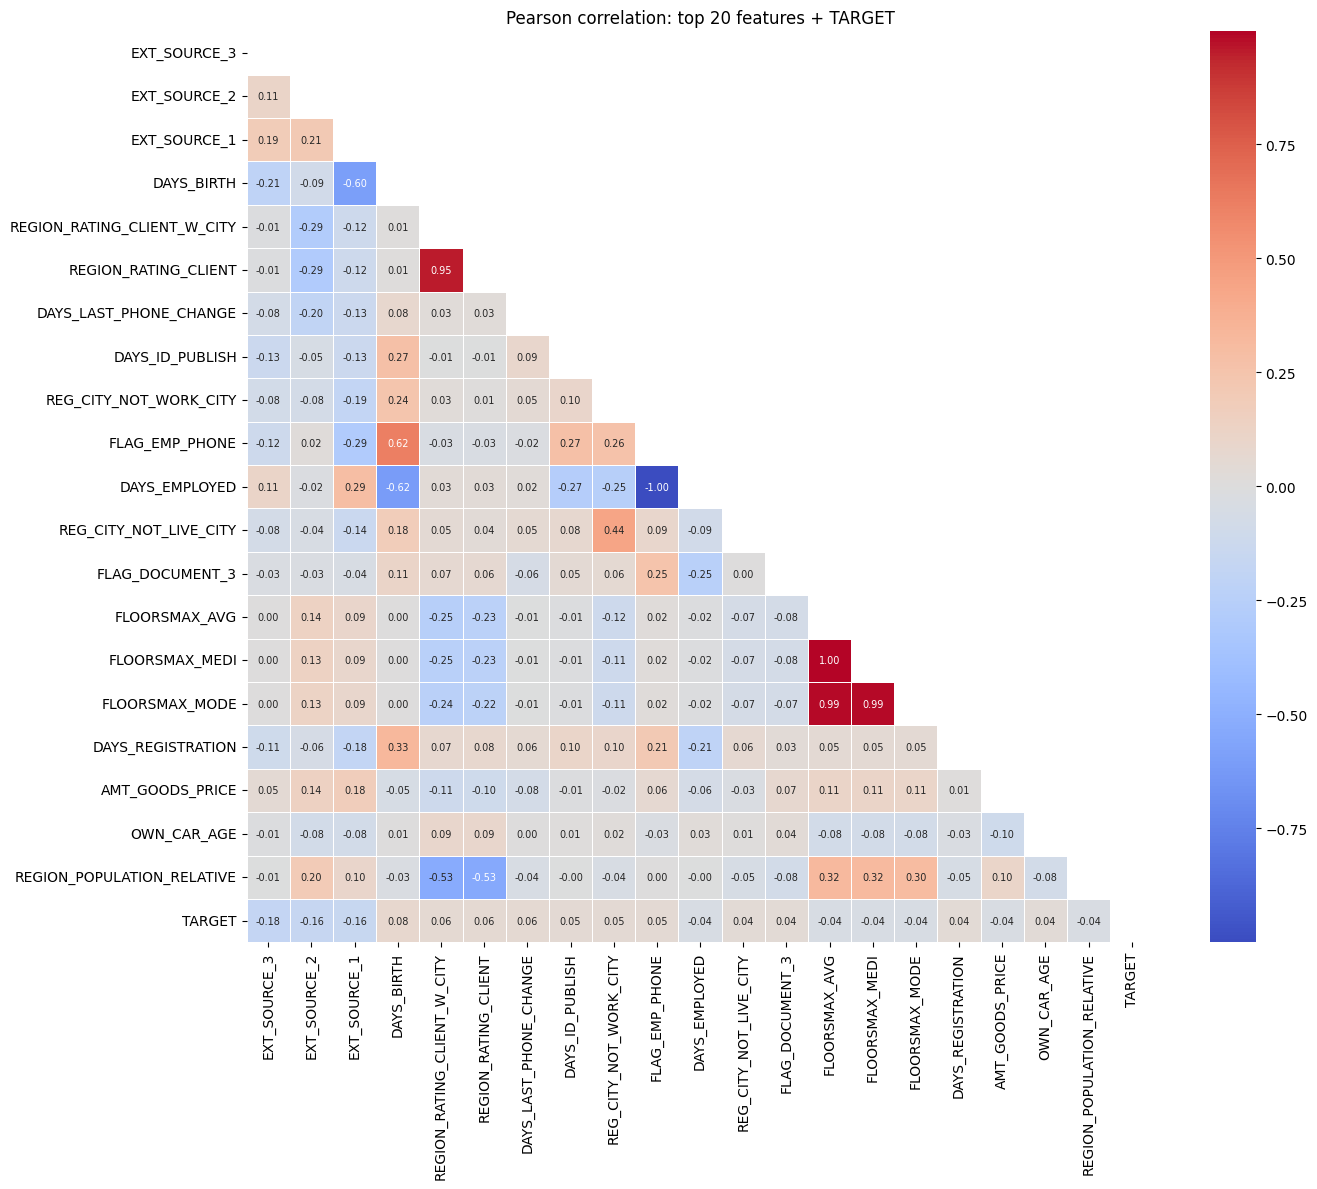

In [31]:
# correlation heatmap of the top 20 features and TARGET.
# upper triangle is masked because the matrix is symmetric (no need to show both halves).
plt.figure(figsize=(14, 12))

# mask hides the upper triangle so only the lower half and diagonal are drawn
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,     # write the numeric value in each cell
    fmt=".2f",      # two decimals
    cmap="coolwarm", center=0,   # blue for negative, red for positive, centered at 0
    linewidths=0.5,
    annot_kws={"size": 7},
)

plt.title("Pearson correlation: top 20 features + TARGET")
plt.tight_layout()
plt.show()

Correlation with TARGET is weak across the board. The strongest is `EXT_SOURCE_3` at -0.18, followed by `EXT_SOURCE_2` and `EXT_SOURCE_1` around -0.16. Everything else sits below 0.1 in absolute value. This is normal for tabular credit data, no single feature is a strong predictor on its own, the signal comes from combinations. It also justifies using non-linear models (MLP, Random Forest) alongside linear ones.

The three `EXT_SOURCE_*` features are the clear winners again. They correlate negatively with TARGET (higher score, lower default) which is the expected direction.

`DAYS_BIRTH` correlates 0.08 with TARGET (younger = more default), matching the age band chart.

Some very strong inter-feature correlations to flag:

- `FLOORSMAX_AVG`, `FLOORSMAX_MEDI`, `FLOORSMAX_MODE` correlate at 0.99-1.00 with each other. Perfect duplicates, same story as the other `_AVG/_MEDI/_MODE` block. Keeping one is enough.
- `REGION_RATING_CLIENT` and `REGION_RATING_CLIENT_W_CITY` correlate at 0.95. Near-duplicates, we can drop one.
- `DAYS_EMPLOYED` and `FLAG_EMP_PHONE` correlate at -1.00. This is suspicious and almost certainly an artifact of the 365243 sentinel: unemployed applicants have the sentinel in `DAYS_EMPLOYED` and 0 in `FLAG_EMP_PHONE`. Once we clean the sentinel, this correlation should drop.
- `DAYS_BIRTH` and `DAYS_EMPLOYED` correlate -0.62, and `DAYS_BIRTH` and `FLAG_EMP_PHONE` at 0.62. Makes sense, older applicants tend to have longer employment history.
- `REGION_POPULATION_RELATIVE` correlates -0.53 with both region ratings. Denser regions tend to have better ratings.


In [32]:
# find all feature pairs with |correlation| > threshold, sorted by strength.
# 0.5 flags both redundant columns (|r| > 0.9) and structural correlations (0.5-0.9).

threshold = 0.5

# mask the lower triangle and diagonal so each pair is counted once
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# flatten the upper triangle into a (feature_1, feature_2) -> correlation series
pairs_series = upper.stack()

# filter by threshold, sort by absolute correlation, format as a dataframe
high_corr_pairs = (
    pairs_series[pairs_series.abs() > threshold]
    .sort_values(key=abs, ascending=False)
    .round(3)
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

if len(high_corr_pairs) > 0:
    display(high_corr_pairs)
else:
    print(f"no pairs with |r| > {threshold} found among the top 20 features by |corr with TARGET|.")

,feature_1,feature_2,correlation
0,FLAG_EMP_PHONE,DAYS_EMPLOYED,-1.000
1,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997
2,FLOORSMAX_MEDI,FLOORSMAX_MODE,0.988
3,FLOORSMAX_AVG,FLOORSMAX_MODE,0.986
4,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT,0.951
5,DAYS_BIRTH,FLAG_EMP_PHONE,0.620
6,DAYS_BIRTH,DAYS_EMPLOYED,-0.616
7,EXT_SOURCE_1,DAYS_BIRTH,-0.601
8,REGION_RATING_CLIENT,REGION_POPULATION_RELATIVE,-0.533
9,REGION_RATING_CLIENT_W_CITY,REGION_POPULATION_RELATIVE,-0.532


## 8. Outlier Scan

we scan the financial fields for extreme values using IQR flags and boxplots.

### 8.1 Overall distributions and IQR flags

histograms and IQR-based outlier flags on the financial fields.

In [33]:
# iqr outlier detection on continuous numeric columns only. we skip binary flags,
# bounded [0,1] columns, discrete counts, and already-handled sentinels because
# iqr fences on those produce meaningless "outliers"

# pick continuous columns with real right tails, same family as the monetary ones
iqr_cols = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE",
    "OWN_CAR_AGE",
    "OBS_30_CNT_SOCIAL_CIRCLE", "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK", "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR",
]
iqr_cols = [c for c in iqr_cols if c in df.columns]

# for days_employed we mask the sentinel 365243 first, otherwise it blows up the iqr
df_iqr = df[iqr_cols].copy()

rows = []
for col in iqr_cols:
    s = df_iqr[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = int(((s < lower) | (s > upper)).sum())
    pct_out = round(n_out / len(s) * 100, 2)
    rows.append({
        "column": col,
        "n_outliers": n_out,
        "pct_outliers": pct_out,
        "lower_fence": round(lower, 2),
        "upper_fence": round(upper, 2),
        "max_value": s.max(),
        "min_value": s.min(),
    })

iqr_summary = pd.DataFrame(rows).sort_values("pct_outliers", ascending=False).reset_index(drop=True)
display(iqr_summary)

,column,n_outliers,pct_outliers,lower_fence,upper_fence,max_value,min_value
0,AMT_REQ_CREDIT_BUREAU_QRT,50575,19.01,0.00,0.00,261.0,0.0
1,AMT_REQ_CREDIT_BUREAU_MON,43759,16.45,0.00,0.00,27.0,0.0
2,DEF_30_CNT_SOCIAL_CIRCLE,35166,11.47,0.00,0.00,34.0,0.0
3,DEF_60_CNT_SOCIAL_CIRCLE,25769,8.41,0.00,0.00,24.0,0.0
4,OBS_30_CNT_SOCIAL_CIRCLE,19971,6.52,-3.00,5.00,348.0,0.0
5,OBS_60_CNT_SOCIAL_CIRCLE,19564,6.38,-3.00,5.00,344.0,0.0
6,AMT_GOODS_PRICE,14728,4.79,-423000.00,1341000.00,4050000.0,40500.0
7,OWN_CAR_AGE,4932,4.72,-10.00,30.00,91.0,0.0
8,AMT_INCOME_TOTAL,14035,4.56,-22500.00,337500.00,117000000.0,25650.0
9,AMT_REQ_CREDIT_BUREAU_WEEK,8536,3.21,0.00,0.00,8.0,0.0


The IQR analysis splits the columns into three groups.

- **Heavy-tailed distributions (>5% flagged as outliers)**: `AMT_REQ_CREDIT_BUREAU_QRT` (19%), `AMT_REQ_CREDIT_BUREAU_MON` (16%), `DEF_30_CNT_SOCIAL_CIRCLE` (11%), `DEF_60_CNT_SOCIAL_CIRCLE` (8.4%), `OBS_30/60_CNT_SOCIAL_CIRCLE` (~6.5%). These are zero-inflated counts where IQR is basically flagging "anything above 0" as an outlier. Not real outliers, just the shape of the data. We will leave them as is.

- **Real right-tail outliers (1-5%)**: `AMT_GOODS_PRICE` (4.8%), `OWN_CAR_AGE` (4.7%), `AMT_INCOME_TOTAL` (4.6%), `AMT_ANNUITY` (2.4%), `AMT_CREDIT` (2.1%). These are the monetary and continuous columns that need winsorization at the 99th percentile.

- **Extreme single-point issues**: look at the max values. `AMT_INCOME_TOTAL` max is 117,000,000 against an upper fence of 337,500 (confirms the documented 117M outlier). `AMT_CREDIT` and `AMT_GOODS_PRICE` both reach 4,050,000. `OBS_30/60_CNT_SOCIAL_CIRCLE` hit 348 and 344 (the extreme points we spotted in the boxplots earlier). `CNT_CHILDREN` max is 19, worth sanity-checking whether that is real.

- **Low/no outlier columns**: `DAYS_REGISTRATION`, `DAYS_LAST_PHONE_CHANGE`, `DAYS_ID_PUBLISH` are clean, negative values as expected.

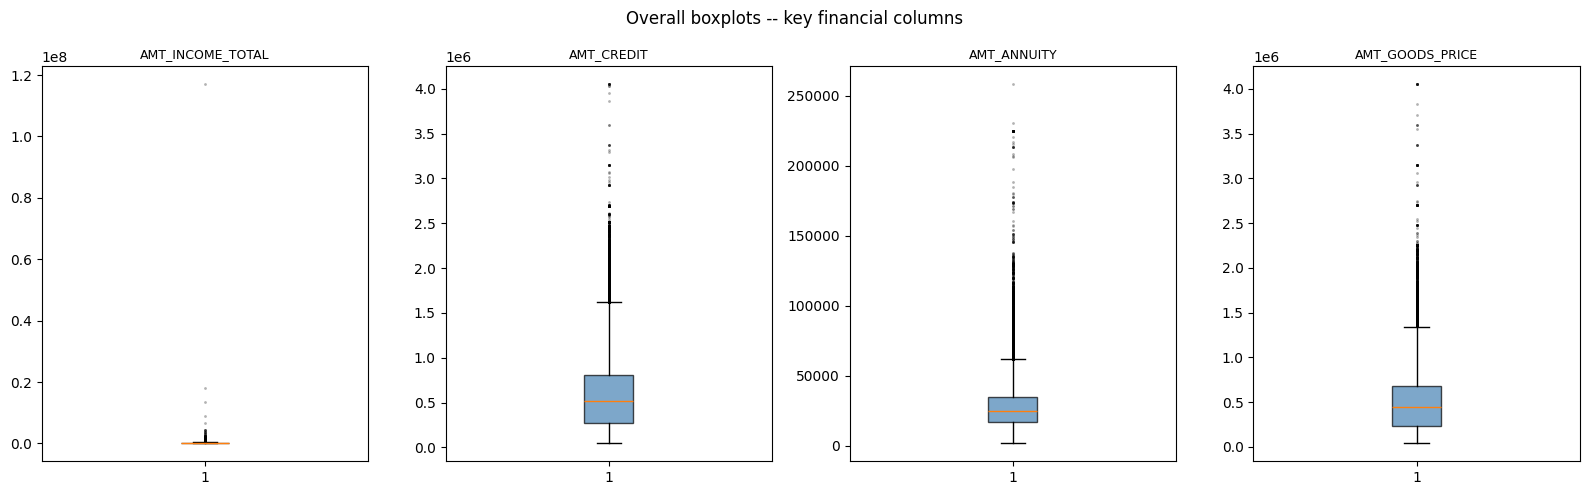

In [34]:
fin_cols = [c for c in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
            if c in df.columns]

fig, axes = plt.subplots(1, len(fin_cols), figsize=(16, 5))
for ax, col in zip(axes, fin_cols):
    ax.boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.7),
        flierprops=dict(marker=".", markersize=2, alpha=0.3)
    )
    ax.set_title(col, fontsize=9)

plt.suptitle("Overall boxplots -- key financial columns")
plt.tight_layout()
plt.show()


- `AMT_INCOME_TOTAL` is the worst case, the box is completely flattened at the bottom because of the 117M outlier stretching the y-axis to 1.2×10⁸. Without capping, any standardization on this column would be dominated by a handful of extreme values.

- `AMT_CREDIT` and `AMT_GOODS_PRICE` look similar to each other, with medians around 500k, IQR up to ~1.5M, and a long tail of outliers reaching 4M.

- `AMT_ANNUITY` follows the same pattern on a smaller scale, median around 25k, outliers above 150k.


### 8.2 Boxplots split by TARGET

Same financial fields, split by defaulter / non-defaulter. Read medians, not whiskers.

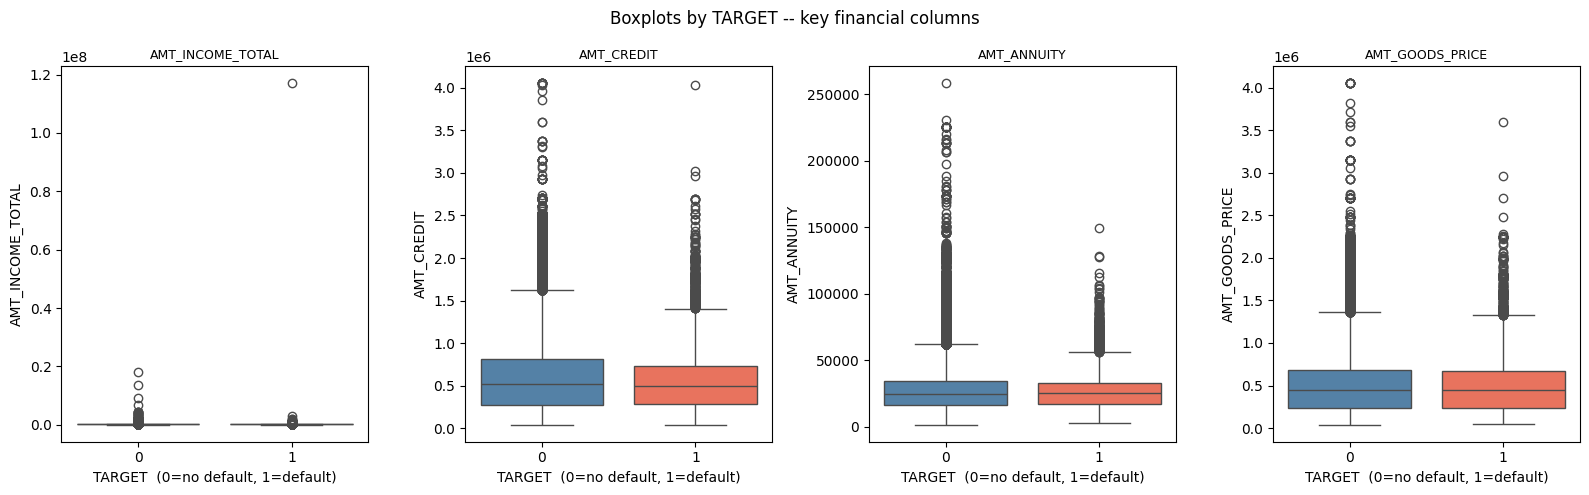

In [35]:
fig, axes = plt.subplots(1, len(fin_cols), figsize=(16, 5))
for ax, col in zip(axes, fin_cols):
    sns.boxplot(
        data=df, x="TARGET", y=col, ax=ax,
        hue="TARGET", palette={0: "steelblue", 1: "tomato"},
        order=[0, 1], legend=False
    )
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("TARGET  (0=no default, 1=default)")

plt.suptitle("Boxplots by TARGET -- key financial columns")
plt.tight_layout()
plt.show()

Same four monetary columns, now split by TARGET. The boxes for defaulters (1) and non-defaulters (0) look almost identical across all four features.

- `AMT_INCOME_TOTAL` is unreadable because of the 117M outlier. The 117M case is a non-defaulter (TARGET=0), which is a small data-cleaning detail worth noting but changes nothing about the conclusion.

- `AMT_CREDIT`: defaulters have a slightly lower median and tighter IQR, but the overlap is massive.

- `AMT_ANNUITY`: essentially identical distributions between the two classes.

- `AMT_GOODS_PRICE`: same story, near-identical boxes.

## 9. Missing Values Audit

we audit which columns are missing and group them by the mechanism that caused the missingness.

The plan asks for a bar chart of % missing per column. We go further: 67 of the 122 columns have at least one missing value, and they do not fail independently. Grouping them by cause reduces a 67-column problem to six mechanisms of different sizes and strengths, which fundamentally changes the preprocessing decision in Phase 2.

We placed this section at the end of the EDA, not at the start as the plan's task ordering suggests, because our grouped-by-cause analysis is the most substantial part of this notebook and reads better as a culmination than as a housekeeping step.

In [36]:
# check for nulls (as percentage)

(df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,69.87
COMMONAREA_MODE,69.87
COMMONAREA_MEDI,69.87
NONLIVINGAPARTMENTS_MEDI,69.43
NONLIVINGAPARTMENTS_MODE,69.43
NONLIVINGAPARTMENTS_AVG,69.43
FONDKAPREMONT_MODE,68.39
LIVINGAPARTMENTS_AVG,68.35
LIVINGAPARTMENTS_MEDI,68.35
LIVINGAPARTMENTS_MODE,68.35


In [37]:
# how many columns have nulls

null_cols = df.isna().sum().gt(0).sum()

print(f'Null columns: {null_cols}')

Null columns: 67


In [38]:
# total nulls in the dataset

total_nulls = df.isna().sum().sum()

total_cells = df.size

print(f"total nulls: {total_nulls:,} ({total_nulls / total_cells * 100:.2f}%)")


total nulls: 9,152,465 (24.40%)


67 out of 122 columns contain nulls, and the total share of missing cells in the dataset is ~24%. Looking at the list, the null pattern is not random: the same column families show identical missing rates (the three `COMMONAREA_*` variants all at 69.87%, the three `NONLIVINGAPARTMENTS_*` at 69.43%, and so on). This tells us the nulls share an upstream cause rather than being 67 independent problems.

To deal with them in a meaningful way, we group the 67 columns by the reason they are missing, based on the data dictionary:

- **G1 building block**: apartment and building features, missing when no appraisal data exists for the building.
- **G2 external scores**: the three `EXT_SOURCE_*` columns, missing when the applicant has no record at that bureau.
- **G3 optional personal**: `OCCUPATION_TYPE` and `NAME_TYPE_SUITE`, missing for pensioners/unemployed or applicants who came alone.
- **G4 bureau enquiries**: `AMT_REQ_CREDIT_BUREAU_*`, missing when the bureau query was not run.
- **G5 social circle**: `OBS_*` and `DEF_*` counts, missing when social-circle data was not collected.
- **G6 isolated small gaps**: a handful of columns with very low missingness (`OWN_CAR_AGE`, `AMT_ANNUITY`, etc.) that do not fit the patterns above.

In [39]:
# define the six missingness groups once, used by every cell below.
# grouping follows the data dictionary's explanations, not an automatic clustering.

g1 = [
    "APARTMENTS_AVG", "APARTMENTS_MODE", "APARTMENTS_MEDI",
    "BASEMENTAREA_AVG", "BASEMENTAREA_MODE", "BASEMENTAREA_MEDI",
    "YEARS_BEGINEXPLUATATION_AVG", "YEARS_BEGINEXPLUATATION_MODE", "YEARS_BEGINEXPLUATATION_MEDI",
    "YEARS_BUILD_AVG", "YEARS_BUILD_MODE", "YEARS_BUILD_MEDI",
    "COMMONAREA_AVG", "COMMONAREA_MODE", "COMMONAREA_MEDI",
    "ELEVATORS_AVG", "ELEVATORS_MODE", "ELEVATORS_MEDI",
    "ENTRANCES_AVG", "ENTRANCES_MODE", "ENTRANCES_MEDI",
    "FLOORSMAX_AVG", "FLOORSMAX_MODE", "FLOORSMAX_MEDI",
    "FLOORSMIN_AVG", "FLOORSMIN_MODE", "FLOORSMIN_MEDI",
    "LANDAREA_AVG", "LANDAREA_MODE", "LANDAREA_MEDI",
    "LIVINGAPARTMENTS_AVG", "LIVINGAPARTMENTS_MODE", "LIVINGAPARTMENTS_MEDI",
    "LIVINGAREA_AVG", "LIVINGAREA_MODE", "LIVINGAREA_MEDI",
    "NONLIVINGAPARTMENTS_AVG", "NONLIVINGAPARTMENTS_MODE", "NONLIVINGAPARTMENTS_MEDI",
    "NONLIVINGAREA_AVG", "NONLIVINGAREA_MODE", "NONLIVINGAREA_MEDI",
    "FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "TOTALAREA_MODE",
    "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE",
]

g2 = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

g3 = ["OCCUPATION_TYPE", "NAME_TYPE_SUITE"]

g4 = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]

g5 = [
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
]

g6 = [
    "OWN_CAR_AGE",
    "CNT_FAM_MEMBERS",
    "DAYS_LAST_PHONE_CHANGE",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

MISSINGNESS_GROUPS = {
    "G1 building block":       g1,
    "G2 external scores":      g2,
    "G3 optional personal":    g3,
    "G4 bureau enquiries":     g4,
    "G5 social circle":        g5,
    "G6 isolated small gaps":  g6,
}

# keep all_missing as a list so downstream cells can iterate it in a fixed order
all_missing = df.columns[df.isnull().any()].tolist()
grouped = set().union(*MISSINGNESS_GROUPS.values())

missing_from_groups = set(all_missing) - grouped
extra_in_groups = grouped - set(df.columns)

print(f"columns with any missing: {len(all_missing)}")
print(f"columns covered by groups: {len(set(all_missing) & grouped)}")
if missing_from_groups:
    print(f"columns with nulls NOT in any group: {missing_from_groups}")
if extra_in_groups:
    print(f"columns in groups but not in df: {extra_in_groups}")

columns with any missing: 67
columns covered by groups: 67


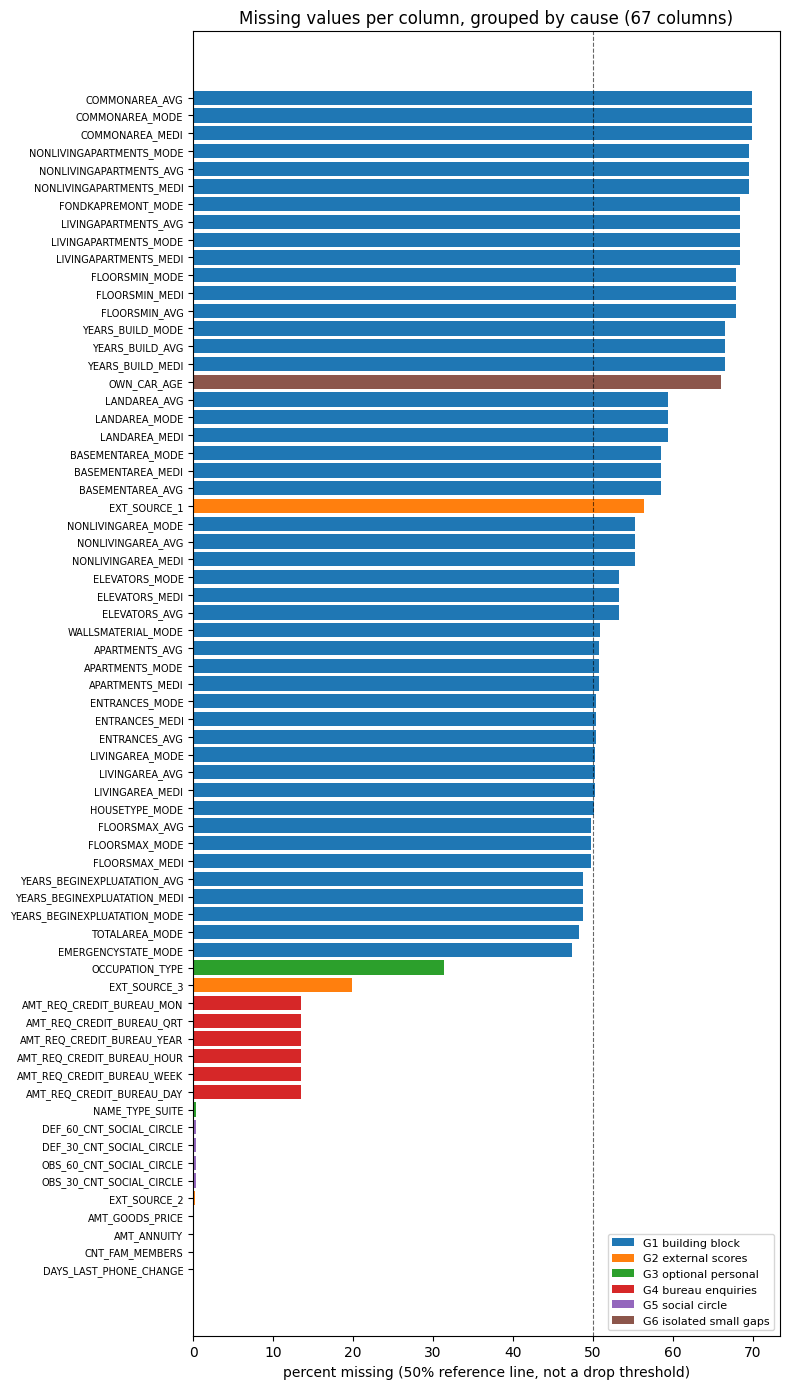

In [40]:
# horizontal bars are a deliberate exception to the vertical-bar house style:
# 67 categories stacked vertically would be unreadable.
# color maps each bar to its missingness group so the clustering is visible at a glance.

group_colors = {
    "G1 building block":       "#1f77b4",
    "G2 external scores":      "#ff7f0e",
    "G3 optional personal":    "#2ca02c",
    "G4 bureau enquiries":     "#d62728",
    "G5 social circle":        "#9467bd",
    "G6 isolated small gaps":  "#8c564b",
}

# reverse-lookup: column name -> group name
col_to_group = {c: g for g, cols in MISSINGNESS_GROUPS.items() for c in cols}

# one row per missing column with its percent missing and its group
miss_df = (
    pd.DataFrame({
        "column": all_missing,
        "pct_missing": [df[c].isnull().mean() * 100 for c in all_missing],
        "group": [col_to_group[c] for c in all_missing],
    })
    .sort_values("pct_missing", ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 14))
colors = [group_colors[g] for g in miss_df["group"]]
plt.barh(range(len(miss_df)), miss_df["pct_missing"], color=colors)
plt.yticks(range(len(miss_df)), miss_df["column"], fontsize=7)
plt.axvline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("percent missing (50% reference line, not a drop threshold)")
plt.title(f"Missing values per column, grouped by cause ({len(miss_df)} columns)")

# one legend entry per group
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=g) for g, c in group_colors.items()]
plt.legend(handles=handles, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()


The chart makes the grouping visible at a glance. The big blue block at the top (G1) is the building-info cascade, all clustered between 47% and 70% missing. The orange bars (G2, external scores) show that `EXT_SOURCE_1` is missing in 56% of cases but `EXT_SOURCE_3` in only 20% and `EXT_SOURCE_2` in less than 1%. The other groups sit well below the 50% reference line.

The 50% line is drawn as a reference, not as an automatic drop threshold. The actual treatment per group in Phase 2 is:

- **G1 building block**: drop the whole block. Imputing 60% of a column with the median means inventing most of the data, and the correlation with TARGET is essentially zero. Top Kaggle solutions on this dataset did not rely on these features either. Regularization cannot recover information that was never there.
- **G2 external scores**: keep. These are the three strongest predictors of default in the whole dataset, so dropping them is not an option even at 56% missingness. Impute with the median and add a binary missingness indicator so the fact of being missing is preserved as its own feature.
- **G3 optional personal**: keep. Missingness here is semantically meaningful (no occupation = pensioner/unemployed, no companion = came alone). Impute with a literal "Missing" category instead of collapsing into the mode.
- **G4 bureau enquiries**: keep. Low missingness (~13%) and potentially useful signal. Plain median imputation, no flag.
- **G5 social circle**: keep. Negligible missingness. Plain median imputation.
- **G6 isolated small gaps**: mostly drop `OWN_CAR_AGE` (too high and too redundant with `FLAG_OWN_CAR`), plain impute the rest.

Net effect: we go from 122 columns to roughly 74, before one-hot encoding expands the categoricals. All imputers will be fit on the training split only and applied to validation and test through the shared Pipeline, to avoid leakage.

# 10. Preprocessing to-do

One row per column or group that needs something done in Phase 2. Columns not listed get default handling (median impute if numeric with nulls, standard scaling if numeric, one-hot if categorical, passthrough if binary with real variance).

Each row gives the committed default treatment. When the choice is non-obvious we list an "alt:" option to sanity-check before locking in the pipeline.

## Drop entirely (49 columns)

| Column | Reason | Alternative |
|---|---|---|
| `SK_ID_CURR` | identifier, not a feature | none |
| `FLAG_MOBIL` | 100% ones, zero variance | none |
| `FLAG_CONT_MOBILE` | near-100% ones, near-zero variance | none |
| `REGION_RATING_CLIENT_W_CITY` | 0.95 correlation with `REGION_RATING_CLIENT`, redundant | alt: keep both and let L1 prune |
| `OWN_CAR_AGE` | 66% missing and redundant with `FLAG_OWN_CAR` | alt: impute median + flag |
| `APARTMENTS_AVG/MODE/MEDI` | G1 building block, 50% missing, ~0 corr with TARGET | alt: keep `_AVG` only with flag |
| `BASEMENTAREA_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `YEARS_BEGINEXPLUATATION_AVG/MODE/MEDI` | G1, also saturated at 1.0 | alt: drop regardless (low variance) |
| `YEARS_BUILD_AVG/MODE/MEDI` | G1, 66% missing | alt: keep `_AVG` only |
| `COMMONAREA_AVG/MODE/MEDI` | G1, 70% missing | alt: keep `_AVG` only |
| `ELEVATORS_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `ENTRANCES_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `FLOORSMAX_AVG/MODE/MEDI` | G1, 0.99 intra-correlation | alt: keep `_AVG` only |
| `FLOORSMIN_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `LANDAREA_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `LIVINGAPARTMENTS_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `LIVINGAREA_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `NONLIVINGAPARTMENTS_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `NONLIVINGAREA_AVG/MODE/MEDI` | G1 | alt: keep `_AVG` only |
| `FONDKAPREMONT_MODE` | G1 categorical variant | none |
| `HOUSETYPE_MODE` | G1 | none |
| `TOTALAREA_MODE` | G1 | alt: keep as single building-block representative |
| `WALLSMATERIAL_MODE` | G1 | none |
| `EMERGENCYSTATE_MODE` | G1 | none |
| `FLAG_DOCUMENT_2/4/7/9/10/12/13/14/15/17/19/20/21` | <1% ones each, near-zero variance | alt: collapse all into single `SUBMITTED_RARE_DOCUMENT` flag |

## Sentinel handling: `DAYS_EMPLOYED`

`DAYS_EMPLOYED` is supposed to be the number of days before the application that the person started their current job. For employed applicants it contains reasonable negative values like `-2300`. For unemployed applicants the dataset uses the fake number `365243` (about 1000 years in days) as a placeholder. This is a **sentinel value**: a number pretending to be a missing value.

If we leave `365243` as a real number, the scaler computes mean and standard deviation including it. The mean gets dragged up, the std explodes, and every other real value gets squashed near zero after scaling. Any model trained on this is poisoned.

The fix is a four-step chain inside the preprocessing pipeline:

1. **Replace `365243` with `NaN`.** This tells pandas "these are not real values, they are missing". At this point the data is not yet ready for the model, because models cannot accept `NaN` either. This step is only a signal to the imputer.
2. **Add a new binary column `DAYS_EMPLOYED_ANOM`.** It is `1` if the original value was the sentinel (the person is unemployed) and `0` otherwise. This preserves the "unemployed" signal as its own feature, so we do not lose that information when we impute.
3. **Impute the `NaN`s with the training median.** Now the `NaN`s from step 1 get filled with a real, reasonable number (something like `-1200` days). After this step there are no `NaN`s left in the column.
4. **Scale with `StandardScaler`.** The scaler sees only reasonable values, so standardisation works correctly.

Flow: `365243 → NaN → median → scaled number → model`. By the time the data reaches the model, there is no `NaN` anymore. The `NaN` only exists as an intermediate state between steps 1 and 3 to let the imputer know which values to fill.

## Impute median + add missingness flag (3 columns)

For columns where the fact that a value is missing is itself informative, we add a binary `_MISSING` column before imputing. This preserves the "was originally missing" signal as a feature, even though the number itself gets filled with the median.

| Column | Reason |
|---|---|
| `EXT_SOURCE_1` | 56% missing but top predictor, flag preserves signal |
| `EXT_SOURCE_2` | <1% missing, top predictor, flag kept for consistency |
| `EXT_SOURCE_3` | 20% missing, top predictor, flag preserves signal |

## Impute median, then scale (13 columns)

Columns with low-to-moderate missingness where the missingness is not particularly informative. Plain median imputation, no flag, then scale.

| Column | Reason |
|---|---|
| `AMT_ANNUITY` | 12 nulls, also winsorized and feeds engineered ratios |
| `AMT_GOODS_PRICE` | 278 nulls, also winsorized and feeds ratios |
| `CNT_FAM_MEMBERS` | 2 nulls, also cap the 20-member outlier (see outlier section) |
| `DEF_30_CNT_SOCIAL_CIRCLE` | 1000 nulls |
| `DEF_60_CNT_SOCIAL_CIRCLE` | 1000 nulls |
| `OBS_30_CNT_SOCIAL_CIRCLE` | 1000 nulls, also cap the 348 outlier (see outlier section) |
| `OBS_60_CNT_SOCIAL_CIRCLE` | 1000 nulls, also cap the 344 outlier (see outlier section) |
| `AMT_REQ_CREDIT_BUREAU_HOUR` | 13% missing |
| `AMT_REQ_CREDIT_BUREAU_DAY` | 13% missing |
| `AMT_REQ_CREDIT_BUREAU_WEEK` | 13% missing |
| `AMT_REQ_CREDIT_BUREAU_MON` | 13% missing |
| `AMT_REQ_CREDIT_BUREAU_QRT` | 13% missing, also cap the 261 outlier (see outlier section) |
| `AMT_REQ_CREDIT_BUREAU_YEAR` | 13% missing |

## Winsorize at 99th percentile, then scale (4 columns, heavy right tail)

Winsorization caps the upper tail at the 99th percentile of the training data. It does not drop rows, it replaces any value above the cutoff with the cutoff value. This stops extreme outliers from dominating the scaler. These four columns share the same right-skewed shape, which is why they get the same treatment.

| Column | Reason | Alternative |
|---|---|---|
| `AMT_INCOME_TOTAL` | 117M outlier, skew 391 | alt: 95th or 99.5th threshold, or log1p before scaling |
| `AMT_CREDIT` | right tail up to 4M | alt: log1p before scaling |
| `AMT_ANNUITY` | right tail up to 258k (also imputed) | alt: log1p before scaling |
| `AMT_GOODS_PRICE` | right tail up to 4M (also imputed) | alt: log1p before scaling |

**Log-transform note:** winsorization caps the top but the distribution remains right-skewed. Applying `log1p` before standard-scaling brings these columns closer to normal, which helps linear models (logistic regression, elastic net) and the MLP. Tree-based models (Random Forest) are invariant to monotone transforms so it does not help them. Decision to make in Phase 2: apply `log1p` on the four monetary columns before scaling, or trust winsorization + scaling alone.

## Cap extreme single-point outliers, then impute median (6 columns, one-off bad values)

Different problem from the winsorization block. These columns are *not* heavy-tailed, they are mostly well-behaved counts with one or two extreme values that are almost certainly data-entry errors or hidden sentinels (e.g. one applicant with 348 people in their social circle, one with 19 children). Winsorizing at the 99th percentile would be too aggressive because 99% of the values are already clean. We cap at a hard-coded safe threshold instead.

| Column | Problem | Treatment |
|---|---|---|
| `OBS_30_CNT_SOCIAL_CIRCLE` | max 348, typical <10 | cap at 99.5th percentile (~ 20), then impute median, then scale |
| `OBS_60_CNT_SOCIAL_CIRCLE` | max 344, typical <10 | cap at 99.5th percentile (~ 20), then impute median, then scale |
| `AMT_REQ_CREDIT_BUREAU_QRT` | max 261, typical 0 | cap at 99.5th percentile, then impute median, then scale |
| `CNT_CHILDREN` | max 19, typical 0-3 | cap at 10, then scale (no nulls so no imputation) |
| `CNT_FAM_MEMBERS` | max 20, typical 1-4 | cap at 10, then impute median, then scale |
| `DEF_30/60_CNT_SOCIAL_CIRCLE` | zero-inflated, no extreme max | skip capping, plain impute handles it |

Hard caps of 10 for `CNT_CHILDREN` and `CNT_FAM_MEMBERS` are chosen because anything above that is implausible and almost certainly a data error. The 99.5th percentile on the social circle and bureau columns is chosen because the distributions are zero-inflated, so a percentile cutoff reflects what "unusual" actually means in those columns.

## Convert DAYS to positive units, then scale (4 columns)

The `DAYS_*` columns store values as negative days counted backwards from the application date (e.g. `-10000` means "10000 days before today"). Negative values are fine mathematically but hard to read, so we flip the sign. For `DAYS_BIRTH` we also divide by 365.25 to get age in years, since age is more interpretable in the fairness analysis later.

| Column | Treatment |
|---|---|
| `DAYS_BIRTH` | convert to `age_years = -DAYS_BIRTH / 365.25`, scale |
| `DAYS_REGISTRATION` | flip sign, scale |
| `DAYS_ID_PUBLISH` | flip sign, scale |
| `DAYS_LAST_PHONE_CHANGE` | flip sign, scale (1 null also imputed) |

## Drop specific rows, then encode (2 columns)

Both columns have a tiny "unclear" category with only a handful of rows. Not enough rows to impute meaningfully, and keeping them adds a spurious onehot column. Drop the rows, then standard onehot on what remains.

| Column | Treatment |
|---|---|
| `CODE_GENDER` | drop 4 `XNA` rows, then onehot (M/F) |
| `NAME_FAMILY_STATUS` | drop 2 `Unknown` rows, then onehot |

## Impute "Missing" category, then onehot (2 columns)

For these two categorical columns the missingness is semantically meaningful: a missing `OCCUPATION_TYPE` usually means "pensioner or unemployed", a missing `NAME_TYPE_SUITE` usually means "came alone". We keep that signal by imputing with a literal string `"Missing"` instead of collapsing into the most frequent category.

| Column | Reason |
|---|---|
| `OCCUPATION_TYPE` | 31% missing, semantic NaN |
| `NAME_TYPE_SUITE` | 0.4% missing, semantic NaN |

## Onehot with rare category grouping (3 columns)

High-cardinality categoricals. Onehot-encoding them as-is would add dozens of sparse columns with almost no signal. Instead, group categories that appear in less than 1% of the training rows into a single `"Other"` bucket, then onehot.

| Column | Treatment | Alternative |
|---|---|---|
| `ORGANIZATION_TYPE` | group <1% into "Other", onehot (58 → ~15 categories) | alt: 0.5% (more granular) or 2% (more aggressive) |
| `NAME_INCOME_TYPE` | group rare into "Other", onehot | alt: keep Maternity and Unemployed as own categories (40% and 36% default rate, strong signal) and group only Student/Businessman |
| `OCCUPATION_TYPE` | group rare occupations into "Other" after imputing "Missing" | alt: adjust 1% threshold up or down |

## Ordinal encode (1 column)

`NAME_EDUCATION_TYPE` has a natural ordering from "least education" to "most education", confirmed in the data dictionary and further supported by the clean monotonic default-rate pattern we saw in section 6.1.

| Column | Treatment |
|---|---|
| `NAME_EDUCATION_TYPE` | map Lower secondary=0, Secondary=1, Incomplete higher=2, Higher education=3, Academic degree=4 |

## Keep as ordinal (1 column)

| Column | Treatment | Alternative |
|---|---|---|
| `REGION_RATING_CLIENT` | keep as 1/2/3 integer, scale | alt: onehot if default rate by rating is not monotonic (to verify in Phase 2) |

## Engineered ratio features (3 new columns)

Three domain-motivated ratios computed from the four monetary columns. These capture relationships that the raw columns alone do not. For example a 500k loan is risky for someone earning 30k but normal for someone earning 300k.

| New Column | Formula | Reason |
|---|---|---|
| `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | domain-standard risk indicator |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | monthly burden vs income |
| `CREDIT_TERM` | `AMT_CREDIT / AMT_ANNUITY` | effective loan length |

All three computed after imputation on the input columns, then winsorized and scaled as their own columns.

## Final count

- Starting columns: 122
- Dropped: 49
- Remaining original: 73
- Engineered added: +3 ratios, +1 flag (`DAYS_EMPLOYED_ANOM`), +3 missingness flags (`EXT_SOURCE_*_MISSING`)
- Before one-hot expansion: **~80 features**
- After one-hot (~12 categoricals expanding to ~40 categories after grouping): **~110-120 features**